In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import MultipleLocator
from math import sqrt
from numpy import concatenate
from pandas import read_csv, DataFrame, concat
from datetime import datetime
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import MinMaxScaler, StandardScaler

import keras.backend as K
from keras.layers import Multiply
from keras.models import Sequential ,Model
from keras.layers import Dense , Input , Reshape , Flatten ,Permute , Lambda , RepeatVector ,Conv1D , MaxPooling1D , Dropout, Bidirectional, Activation
from keras.layers import GRU, LSTM
from keras.utils.vis_utils import plot_model
from keras.optimizers import SGD,Adam
from keras.utils import np_utils   #np_utils
from keras.callbacks import TensorBoard  #TensorBoard可视化

Using TensorFlow backend.


In [2]:
# T:0
# H:1
# Surge:2
# Heave:4
# Force1:8
data_1 = pd.read_csv('t_1.csv')
data_1.head()

,T,H,Surge,Sway,Heave,Roll,Pitch,Yaw,Force1,Force2
0,0.1,-277.0,-2.36,0.000849,-15.1,3.230000e-09,-0.0121,-1.980000e-09,4890.0,5070.0
1,1.1,-591.0,-30.10,-0.185000,-448.0,3.090000e-05,-0.0156,-1.650000e-05,4260.0,4680.0
2,2.1,-457.0,-112.00,1.570000,-422.0,5.970000e-04,0.0303,1.440000e-04,4320.0,4680.0
3,3.1,85.5,28.00,-0.265000,51.0,-3.080000e-04,0.0570,1.300000e-04,5580.0,4610.0
4,4.1,618.0,95.70,-2.900000,488.0,3.310000e-05,0.0352,2.270000e-04,6180.0,5040.0


In [3]:
data_distance = np.hstack((np.array(data_1)[:, 1:8], np.array(data_1)[:, 8:10]))
print(data_distance)
print(data_distance.shape)

[[-2.77e+02 -2.36e+00  8.49e-04 ... -1.98e-09  4.89e+03  5.07e+03]
 [-5.91e+02 -3.01e+01 -1.85e-01 ... -1.65e-05  4.26e+03  4.68e+03]
 [-4.57e+02 -1.12e+02  1.57e+00 ...  1.44e-04  4.32e+03  4.68e+03]
 ...
 [ 3.29e+02  1.75e+02 -6.20e+00 ... -6.95e-05  6.32e+03  4.61e+03]
 [ 8.32e+02  1.92e+02 -3.20e+00 ...  4.27e-04  6.59e+03  4.96e+03]
 [ 7.99e+02  1.13e+02  1.83e+00 ...  8.30e-05  6.02e+03  5.51e+03]]
(11000, 9)


In [4]:
H_scaler = MinMaxScaler(feature_range=(-1, 1))
H = H_scaler.fit_transform(data_distance[:,0:1])
Surge_scaler = MinMaxScaler(feature_range=(-1, 1))
Surge = Surge_scaler.fit_transform(data_distance[:,1:2])
Sway_scaler = MinMaxScaler(feature_range=(-1, 1))
Sway = Sway_scaler.fit_transform(data_distance[:,2:3])
Heave_scaler = MinMaxScaler(feature_range=(-1, 1))
Heave = Heave_scaler.fit_transform(data_distance[:,3:4])
Roll_scaler = MinMaxScaler(feature_range=(-1, 1))
Roll = Roll_scaler.fit_transform(data_distance[:,4:5]*1e6)
Pitch_scaler = MinMaxScaler(feature_range=(-1, 1))
Pitch = Pitch_scaler.fit_transform(data_distance[:,5:6])
Yaw_scaler = MinMaxScaler(feature_range=(-1, 1))
Yaw = Yaw_scaler.fit_transform(data_distance[:,6:7]*1e6)
Force1_scaler = MinMaxScaler(feature_range=(-1, 1))
Force1 = Force1_scaler.fit_transform(data_distance[:,7:8])
Force2_scaler = MinMaxScaler(feature_range=(-1, 1))
Force2 = Force2_scaler.fit_transform(data_distance[:,8:9])
# zong_data = np.hstack(())

In [5]:
# LSTM
def Model_LSTM(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(LSTM(25, activation='tanh', input_shape=(train_X.shape[1], train_X.shape[2])))  #25×5的数据输入
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y

def series_to_supervised(data, n_in, n_out, dropnan=True):
#      '''
#      说明：将每一个特征（输入+输出）的单步-目标步长数全数列举出来
#      '''
    n_vars = 1 if type(data) is list else data.shape[1]
    df = DataFrame(data)
    cols, names = list(), list()
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
    agg = concat(cols, axis=1)
    agg.columns = names
    if dropnan:
        agg.dropna(inplace=True)
    return agg
def deal_data1(data, features_number, time_steps):
    '''
    适用：单/多特征，单/多预测步长
    data：数据集（仅包括输入+输出，且输出仅有一列并在最后）
    feature_number：输入+输出变量数
    n_in：预测步长
    结果解释：输入+输出+所需预测步长的输出（当为单特征时，输入、输出为同一列）
    '''
    process_data = series_to_supervised(data, time_steps, 1, dropnan=True)
    a = []
    for i in range(features_number, features_number*(time_steps+1)-1):
        a.append(i)
        i = i+1
    process_data.drop(process_data.columns[a], axis=1, inplace=True)
    return process_data.values
def deal_data2(data, features_number, time_steps):
    '''
    适用：多特征，单/多预测步长，不适用于单特征
    data：数据集（仅包括输入+输出，且输出仅有一列并在最后）
    feature_number：输入+输出变量数
    n_in：预测步长
    结果解释：输入+所需预测步长的输出
    '''
    process_data = series_to_supervised(data, time_steps, 1, dropnan=True)
    a = []
    for i in range(features_number-1, features_number*(time_steps+1)-1):
        a.append(i)
        i = i+1
    process_data.drop(process_data.columns[a], axis=1, inplace=True)
    return process_data.values
def split_sequence(dataset, n_past):
    x, y = list(), list()
    for i in range(len(dataset)):
        end_ix = i + n_past
        if end_ix > len(dataset):
            break
        seq_x, seq_y = dataset[i:end_ix, :-1], dataset[i, -1]
        x.append(seq_x)
        y.append(seq_y)
    return np.array(x), np.array(y)

def loss_plot(history, epo, length, width):
    # plot history
    plt.figure(figsize = (length, width))
    # 将x周的刻度线方向设置向内
    plt.rcParams['xtick.direction'] = 'in'  
    # 将y轴的刻度方向设置向内
    plt.rcParams['ytick.direction'] = 'in'  
    #设置字体以便支持中文
    plt.rcParams['font.sans-serif']=['SimHei']
    #为正常显示负号
    plt.rcParams['axes.unicode_minus'] = False 
    plt.plot(history.history['loss'], label = 'train loss')
    plt.plot(history.history['val_loss'], label = 'valid loss')
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()
    print(np.hstack((np.array(history.history['loss']).reshape(epo,1), np.array(history.history['val_loss']).reshape(epo,1))))

from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
def evaluate(valid_y,pre_Y):
    XP1 = valid_y.copy()
    XA1 = pre_Y.copy()
    #c =abs((XP-XA)/XA)
    c1 =abs((XP1-XA1))
    #MAPE = (c.sum())/(c.shape[0])
    MAE1 = (c1.sum())/(c1.shape[0])
    print('MAE:',MAE1)
    print('MAE(sklearn):', mean_absolute_error(XP1, XA1))
    print('MAPE(sklearn):', mean_absolute_percentage_error(XP1, XA1))

    #MSE
    r1 = ((XP1-XA1)*(XP1-XA1)).sum()/(XP1.shape[0])
    #RMSE = np.sqrt(r)
    MSE1 = r1
    print('MSE:', MSE1)
    print('MSE(sklearn):', mean_squared_error(XP1, XA1))
    print('RMSE(sklearn):',np.sqrt(mean_squared_error(XP1, XA1)))
#     #R^2
#     XM1 = XA1.sum()/(XA1.shape[0])
#     R2_1 = 1-(((XP1-XA1)*(XP1-XA1)).sum()/((XM1-XA1)*(XM1-XA1)).sum())
#     print('R^2:', R2_1)
#     print('R^2(sklearn):', r2_score(XP1, XA1))

    real1 = np.trapz(abs((XP1 - (XP1.sum()/(XP1.shape[0])))).reshape(XP1.shape[0],), dx=0.1)
    pre1 = np.trapz(abs((XA1 - (XP1.sum()/(XP1.shape[0])))).reshape(XA1.shape[0],), dx=0.1)
    Acc1 = 1 - abs(1 - (pre1/real1))
    print('Acc:', Acc1)

def FanGuiHua_surge(valid_sur_y,sur_pre_Y):
    fan_surge_real=Surge_scaler.inverse_transform(valid_sur_y)
    fan_surge_pre=Surge_scaler.inverse_transform(sur_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_surge_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_surge_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_surge_real,fan_surge_pre)
    return fan_surge_real,fan_surge_pre
def FanGuiHua_pitch(valid_pit_y,pit_pre_Y):
    fan_pitch_real=Pitch_scaler.inverse_transform(valid_pit_y)
    fan_pitch_pre=Pitch_scaler.inverse_transform(pit_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_pitch_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_pitch_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_pitch_real,fan_pitch_pre)
    return fan_pitch_real,fan_pitch_pre
def FanGuiHua_sway(valid_sway_y,sway_pre_Y):
    fan_sway_real=Sway_scaler.inverse_transform(valid_sway_y)
    fan_sway_pre=Sway_scaler.inverse_transform(sway_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_sway_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_sway_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_sway_real,fan_sway_pre)
    return fan_sway_real,fan_sway_pre
def FanGuiHua_roll(valid_roll_y,roll_pre_Y):
    fan_roll_real=Roll_scaler.inverse_transform(valid_roll_y)
    fan_roll_pre=Roll_scaler.inverse_transform(roll_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_roll_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_roll_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_roll_real,fan_roll_pre)
    return fan_roll_real,fan_roll_pre
def FanGuiHua_yaw(valid_yaw_y,yaw_pre_Y):
    fan_yaw_real=Yaw_scaler.inverse_transform(valid_yaw_y)
    fan_yaw_pre=Yaw_scaler.inverse_transform(yaw_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_yaw_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_yaw_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_yaw_real,fan_yaw_pre)
    return fan_yaw_real,fan_yaw_pre
def FanGuiHua_heave(valid_hea_y,hea_pre_Y):
    fan_heave_real=Heave_scaler.inverse_transform(valid_hea_y)
    fan_heave_pre=Heave_scaler.inverse_transform(hea_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_heave_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_heave_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_heave_real,fan_heave_pre)
    return fan_heave_real,fan_heave_pre
def FanGuiHua_force1(valid_for1_y,for1_pre_Y):
    fan_force1_real=Force1_scaler.inverse_transform(valid_for1_y)
    fan_force1_pre=Force1_scaler.inverse_transform(for1_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_force1_real,color='blue',label='real')   #真实曲线
    plt.plot(fan_force1_pre,color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_force1_real,fan_force1_pre)
    return fan_force1_real,fan_force1_pre
def FanGuiHua_force2(valid_for2_y,for2_pre_Y):
    fan_force2_real=Force2_scaler.inverse_transform(valid_for2_y)
    fan_force2_pre=Force2_scaler.inverse_transform(for2_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_force2_real,color='blue',label='real')   #真实曲线
    plt.plot(fan_force2_pre,color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_force2_real,fan_force2_pre)
    return fan_force2_real,fan_force2_pre

# 训练量=n_train_times_end-n_train_times_start
def split_train_valid(data_X, data_Y, n_train_times_start, n_train_times_end, n_valid_times):
    '''
    说明：将数据集划分为训练集和验证集
    疑问：先数据切割重组再划分数据集，先划分数据集再数据切割重组，有何区别影响？
    '''
    train_x, valid_x = data_X[n_train_times_start:n_train_times_end, :], data_X[n_train_times_end:n_valid_times, :]
    train_y, valid_y = data_Y[n_train_times_start:n_train_times_end], data_Y[n_train_times_end:n_valid_times]
    train_y = train_y.reshape((n_train_times_end-n_train_times_start, 1))
    valid_y = valid_y.reshape((n_valid_times-n_train_times_end, 1))
    return train_x, train_y, valid_x, valid_y

In [6]:
def Model_NN1(train_X, train_Y, valid_X, valid_Y, feature_number, lr=0.01, epochs=20, batch_size=256):
    input_layer = Input(shape=(feature_number,)) 
    D_layer1 = Dense(units = 150, activation = 'tanh')(input_layer)
    D_layer2 = Dense(units = 150, activation = 'tanh')(D_layer1)
    D_layer3 = Dense(units = 150, activation = 'tanh')(D_layer2)
    output_layer = Dense(1, activation = 'linear')(D_layer2)
    model = Model(inputs = input_layer, outputs = output_layer)
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_train_Y = model.predict(train_X)
    pre_Y = model.predict(valid_X)
    return model, history, pre_train_Y, pre_Y

In [7]:
def Model_NN(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential() #初始化模型
    model.add(Dense(150,input_shape=(train_X.shape[1], ),activation='tanh')) #添加一个隐含层，注：只是第一个隐含层需指定input_dim
    model.add(Dense(150,activation='tanh'))
    model.add(Dense(150,activation='tanh'))
    model.add(Dense(1,activation='linear')) #添加输出层
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_train_Y = model.predict(train_X)
    pre_Y = model.predict(valid_X)
    return model, history, pre_train_Y, pre_Y

In [8]:
# 归一化后的两个数据集
# 波浪-运动响应
# Force
# 输入50步长输出1步长
force150_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[350:,:], 4, 50)
force150_x1,force150_y1 = split_sequence(force150_scaled1, 50)
print(force150_x1.shape)
# 输入100步长输出1步长
force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
print(force1100_x1.shape)



# 输入50步长输出3步长
force150_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[348:,:], 4, 52)
force150_x3,force150_y3 = split_sequence(force150_scaled3, 50)
print(force150_x3.shape)
# 输入100步长输出3步长
force1100_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[298:,:], 4, 102)
force1100_x3,force1100_y3 = split_sequence(force1100_scaled3, 100)
print(force1100_x3.shape)



# 输入50步长输出5步长
force150_scaled5 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[346:,:], 4, 54)
force150_x5,force150_y5 = split_sequence(force150_scaled5, 50)
print(force150_x5.shape)
# 输入100步长输出5步长
force1100_scaled5 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[296:,:], 4, 104)
force1100_x5,force1100_y5 = split_sequence(force1100_scaled5, 100)
print(force1100_x5.shape)



# 输入50步长输出7步长
force150_scaled7 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[344:,:], 4, 56)
force150_x7,force150_y7 = split_sequence(force150_scaled7, 50)
print(force150_x7.shape)
# 输入100步长输出7步长
force1100_scaled7 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[294:,:], 4, 106)
force1100_x7,force1100_y7 = split_sequence(force1100_scaled7, 100)
print(force1100_x7.shape)



# 输入50步长输出9步长
force150_scaled9 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[342:,:], 4, 58)
force150_x9,force150_y9 = split_sequence(force150_scaled9, 50)
print(force150_x9.shape)
# 输入100步长输出9步长
force1100_scaled9 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[292:,:], 4, 108)
force1100_x9,force1100_y9 = split_sequence(force1100_scaled9, 100)
print(force1100_x9.shape)



# 输入50步长输出2步长
force150_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[349:,:], 4, 51)
force150_x2,force150_y2 = split_sequence(force150_scaled2, 50)
print(force150_x2.shape)
# 输入100步长输出2步长
force1100_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[299:,:], 4, 101)
force1100_x2,force1100_y2 = split_sequence(force1100_scaled2, 100)
print(force1100_x2.shape)


# 输入50步长输出4步长
force150_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[347:,:], 4, 53)
force150_x4,force150_y4 = split_sequence(force150_scaled4, 50)
print(force150_x4.shape)
# 输入100步长输出4步长
force1100_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[297:,:], 4, 103)
force1100_x4,force1100_y4 = split_sequence(force1100_scaled4, 100)
print(force1100_x4.shape)



# 输入50步长输出6步长
force150_scaled6 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[345:,:], 4, 55)
force150_x6,force150_y6 = split_sequence(force150_scaled6, 50)
print(force150_x6.shape)
# 输入100步长输出6步长
force1100_scaled6 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[295:,:], 4, 105)
force1100_x6,force1100_y6 = split_sequence(force1100_scaled6, 100)
print(force1100_x6.shape)



# 输入50步长输出8步长
force150_scaled8 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[343:,:], 4, 57)
force150_x8,force150_y8 = split_sequence(force150_scaled8, 50)
print(force150_x8.shape)
# 输入100步长输出8步长
force1100_scaled8 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[293:,:], 4, 107)
force1100_x8,force1100_y8 = split_sequence(force1100_scaled8, 100)
print(force1100_x8.shape)

(10551, 50, 3)
(10501, 100, 3)
(10551, 50, 3)
(10501, 100, 3)
(10551, 50, 3)
(10501, 100, 3)
(10551, 50, 3)
(10501, 100, 3)
(10551, 50, 3)
(10501, 100, 3)
(10551, 50, 3)
(10501, 100, 3)
(10551, 50, 3)
(10501, 100, 3)
(10551, 50, 3)
(10501, 100, 3)
(10551, 50, 3)
(10501, 100, 3)


In [9]:
# 归一化后的两个数据集
# 波浪-运动响应
# 归一化后的两个数据集
# 波浪-运动响应
# Heave
# 输入50步长输出1步长
heave50_scaled1 = deal_data2(np.hstack((H,Heave))[350:,:], 2, 50)
heave50_x1,heave50_y1 = split_sequence(heave50_scaled1, 50)
print(heave50_x1.shape)
# 输入100步长输出1步长
heave100_scaled1 = deal_data2(np.hstack((H,Heave))[300:,:], 2, 100)
heave100_x1,heave100_y1 = split_sequence(heave100_scaled1, 100)
print(heave100_x1.shape)



# 输入50步长输出3步长
heave50_scaled3 = deal_data2(np.hstack((H,Heave))[348:,:], 2, 52)
heave50_x3,heave50_y3 = split_sequence(heave50_scaled3, 50)
print(heave50_x3.shape)
# 输入100步长输出3步长
heave100_scaled3 = deal_data2(np.hstack((H,Heave))[298:,:], 2, 102)
heave100_x3,heave100_y3 = split_sequence(heave100_scaled3, 100)
print(heave100_x3.shape)



# 输入50步长输出5步长
heave50_scaled5 = deal_data2(np.hstack((H,Heave))[346:,:], 2, 54)
heave50_x5,heave50_y5 = split_sequence(heave50_scaled5, 50)
print(heave50_x5.shape)
# 输入100步长输出5步长
heave100_scaled5 = deal_data2(np.hstack((H,Heave))[296:,:], 2, 104)
heave100_x5,heave100_y5 = split_sequence(heave100_scaled5, 100)
print(heave100_x5.shape)



# 输入50步长输出7步长
heave50_scaled7 = deal_data2(np.hstack((H,Heave))[344:,:], 2, 56)
heave50_x7,heave50_y7 = split_sequence(heave50_scaled7, 50)
print(heave50_x7.shape)
# 输入100步长输出7步长
heave100_scaled7 = deal_data2(np.hstack((H,Heave))[294:,:], 2, 106)
heave100_x7,heave100_y7 = split_sequence(heave100_scaled7, 100)
print(heave100_x7.shape)



# 输入50步长输出9步长
heave50_scaled9 = deal_data2(np.hstack((H,Heave))[342:,:], 2, 58)
heave50_x9,heave50_y9 = split_sequence(heave50_scaled9, 50)
print(heave50_x9.shape)
# 输入100步长输出9步长
heave100_scaled9 = deal_data2(np.hstack((H,Heave))[292:,:], 2, 108)
heave100_x9,heave100_y9 = split_sequence(heave100_scaled9, 100)
print(heave100_x9.shape)



# 输入50步长输出2步长
heave50_scaled2 = deal_data2(np.hstack((H,Heave))[349:,:], 2, 51)
heave50_x2,heave50_y2 = split_sequence(heave50_scaled2, 50)
print(heave50_x2.shape)
# 输入100步长输出2步长
heave100_scaled2 = deal_data2(np.hstack((H,Heave))[299:,:], 2, 101)
heave100_x2,heave100_y2 = split_sequence(heave100_scaled2, 100)
print(heave100_x2.shape)


# 输入50步长输出4步长
heave50_scaled4 = deal_data2(np.hstack((H,Heave))[347:,:], 2, 53)
heave50_x4,heave50_y4 = split_sequence(heave50_scaled4, 50)
print(heave50_x4.shape)
# 输入100步长输出4步长
heave100_scaled4 = deal_data2(np.hstack((H,Heave))[297:,:], 2, 103)
heave100_x4,heave100_y4 = split_sequence(heave100_scaled4, 100)
print(heave100_x4.shape)



# 输入50步长输出6步长
heave50_scaled6 = deal_data2(np.hstack((H,Heave))[345:,:], 2, 55)
heave50_x6,heave50_y6 = split_sequence(heave50_scaled6, 50)
print(heave50_x6.shape)
# 输入100步长输出6步长
heave100_scaled6 = deal_data2(np.hstack((H,Heave))[295:,:], 2, 105)
heave100_x6,heave100_y6 = split_sequence(heave100_scaled6, 100)
print(heave100_x6.shape)



# 输入50步长输出8步长
heave50_scaled8 = deal_data2(np.hstack((H,Heave))[343:,:], 2, 57)
heave50_x8,heave50_y8 = split_sequence(heave50_scaled8, 50)
print(heave50_x8.shape)
# 输入100步长输出8步长
heave100_scaled8 = deal_data2(np.hstack((H,Heave))[293:,:], 2, 107)
heave100_x8,heave100_y8 = split_sequence(heave100_scaled8, 100)
print(heave100_x8.shape)


# Surge
# 输入50步长输出1步长
surge50_scaled1 = deal_data2(np.hstack((H,Surge))[350:,:], 2, 50)
surge50_x1,surge50_y1 = split_sequence(surge50_scaled1, 50)
print(surge50_x1.shape)
# 输入100步长输出1步长
surge100_scaled1 = deal_data2(np.hstack((H,Surge))[300:,:], 2, 100)
surge100_x1,surge100_y1 = split_sequence(surge100_scaled1, 100)
print(surge100_x1.shape)



# 输入50步长输出3步长
surge50_scaled3 = deal_data2(np.hstack((H,Surge))[348:,:], 2, 52)
surge50_x3,surge50_y3 = split_sequence(surge50_scaled3, 50)
print(surge50_x3.shape)
# 输入100步长输出3步长
surge100_scaled3 = deal_data2(np.hstack((H,Surge))[298:,:], 2, 102)
surge100_x3,surge100_y3 = split_sequence(surge100_scaled3, 100)
print(surge100_x3.shape)



# 输入50步长输出5步长
surge50_scaled5 = deal_data2(np.hstack((H,Surge))[346:,:], 2, 54)
surge50_x5,surge50_y5 = split_sequence(surge50_scaled5, 50)
print(surge50_x5.shape)
# 输入100步长输出5步长
surge100_scaled5 = deal_data2(np.hstack((H,Surge))[296:,:], 2, 104)
surge100_x5,surge100_y5 = split_sequence(surge100_scaled5, 100)
print(surge100_x5.shape)



# 输入50步长输出7步长
surge50_scaled7 = deal_data2(np.hstack((H,Surge))[344:,:], 2, 56)
surge50_x7,surge50_y7 = split_sequence(surge50_scaled7, 50)
print(surge50_x7.shape)
# 输入100步长输出7步长
surge100_scaled7 = deal_data2(np.hstack((H,Surge))[294:,:], 2, 106)
surge100_x7,surge100_y7 = split_sequence(surge100_scaled7, 100)
print(surge100_x7.shape)



# 输入50步长输出9步长
surge50_scaled9 = deal_data2(np.hstack((H,Surge))[342:,:], 2, 58)
surge50_x9,surge50_y9 = split_sequence(surge50_scaled9, 50)
print(surge50_x9.shape)
# 输入100步长输出9步长
surge100_scaled9 = deal_data2(np.hstack((H,Surge))[292:,:], 2, 108)
surge100_x9,surge100_y9 = split_sequence(surge100_scaled9, 100)
print(surge100_x9.shape)



# 输入50步长输出2步长
surge50_scaled2 = deal_data2(np.hstack((H,Surge))[349:,:], 2, 51)
surge50_x2,surge50_y2 = split_sequence(surge50_scaled2, 50)
print(surge50_x2.shape)
# 输入100步长输出2步长
surge100_scaled2 = deal_data2(np.hstack((H,Surge))[299:,:], 2, 101)
surge100_x2,surge100_y2 = split_sequence(surge100_scaled2, 100)
print(surge100_x2.shape)


# 输入50步长输出4步长
surge50_scaled4 = deal_data2(np.hstack((H,Surge))[347:,:], 2, 53)
surge50_x4,surge50_y4 = split_sequence(surge50_scaled4, 50)
print(surge50_x4.shape)
# 输入100步长输出4步长
surge100_scaled4 = deal_data2(np.hstack((H,Surge))[297:,:], 2, 103)
surge100_x4,surge100_y4 = split_sequence(surge100_scaled4, 100)
print(surge100_x4.shape)



# 输入50步长输出6步长
surge50_scaled6 = deal_data2(np.hstack((H,Surge))[345:,:], 2, 55)
surge50_x6,surge50_y6 = split_sequence(surge50_scaled6, 50)
print(surge50_x6.shape)
# 输入100步长输出6步长
surge100_scaled6 = deal_data2(np.hstack((H,Surge))[295:,:], 2, 105)
surge100_x6,surge100_y6 = split_sequence(surge100_scaled6, 100)
print(surge100_x6.shape)



# 输入50步长输出8步长
surge50_scaled8 = deal_data2(np.hstack((H,Surge))[343:,:], 2, 57)
surge50_x8,surge50_y8 = split_sequence(surge50_scaled8, 50)
print(surge50_x8.shape)
# 输入100步长输出8步长
surge100_scaled8 = deal_data2(np.hstack((H,Surge))[293:,:], 2, 107)
surge100_x8,surge100_y8 = split_sequence(surge100_scaled8, 100)
print(surge100_x8.shape)


# Pitch
# 输入50步长输出1步长
pitch50_scaled1 = deal_data2(np.hstack((H,Pitch))[350:,:], 2, 50)
pitch50_x1,pitch50_y1 = split_sequence(pitch50_scaled1, 50)
print(pitch50_x1.shape)
# 输入100步长输出1步长
pitch100_scaled1 = deal_data2(np.hstack((H,Pitch))[300:,:], 2, 100)
pitch100_x1,pitch100_y1 = split_sequence(pitch100_scaled1, 100)
print(pitch100_x1.shape)



# 输入50步长输出3步长
pitch50_scaled3 = deal_data2(np.hstack((H,Pitch))[348:,:], 2, 52)
pitch50_x3,pitch50_y3 = split_sequence(pitch50_scaled3, 50)
print(pitch50_x3.shape)
# 输入100步长输出3步长
pitch100_scaled3 = deal_data2(np.hstack((H,Pitch))[298:,:], 2, 102)
pitch100_x3,pitch100_y3 = split_sequence(pitch100_scaled3, 100)
print(pitch100_x3.shape)



# 输入50步长输出5步长
pitch50_scaled5 = deal_data2(np.hstack((H,Pitch))[346:,:], 2, 54)
pitch50_x5,pitch50_y5 = split_sequence(pitch50_scaled5, 50)
print(pitch50_x5.shape)
# 输入100步长输出5步长
pitch100_scaled5 = deal_data2(np.hstack((H,Pitch))[296:,:], 2, 104)
pitch100_x5,pitch100_y5 = split_sequence(pitch100_scaled5, 100)
print(pitch100_x5.shape)



# 输入50步长输出7步长
pitch50_scaled7 = deal_data2(np.hstack((H,Pitch))[344:,:], 2, 56)
pitch50_x7,pitch50_y7 = split_sequence(pitch50_scaled7, 50)
print(pitch50_x7.shape)
# 输入100步长输出7步长
pitch100_scaled7 = deal_data2(np.hstack((H,Pitch))[294:,:], 2, 106)
pitch100_x7,pitch100_y7 = split_sequence(pitch100_scaled7, 100)
print(pitch100_x7.shape)



# 输入50步长输出9步长
pitch50_scaled9 = deal_data2(np.hstack((H,Pitch))[342:,:], 2, 58)
pitch50_x9,pitch50_y9 = split_sequence(pitch50_scaled9, 50)
print(pitch50_x9.shape)
# 输入100步长输出9步长
pitch100_scaled9 = deal_data2(np.hstack((H,Pitch))[292:,:], 2, 108)
pitch100_x9,pitch100_y9 = split_sequence(pitch100_scaled9, 100)
print(pitch100_x9.shape)



# 输入50步长输出2步长
pitch50_scaled2 = deal_data2(np.hstack((H,Pitch))[349:,:], 2, 51)
pitch50_x2,pitch50_y2 = split_sequence(pitch50_scaled2, 50)
print(pitch50_x2.shape)
# 输入100步长输出2步长
pitch100_scaled2 = deal_data2(np.hstack((H,Pitch))[299:,:], 2, 101)
pitch100_x2,pitch100_y2 = split_sequence(pitch100_scaled2, 100)
print(pitch100_x2.shape)


# 输入50步长输出4步长
pitch50_scaled4 = deal_data2(np.hstack((H,Pitch))[347:,:], 2, 53)
pitch50_x4,pitch50_y4 = split_sequence(pitch50_scaled4, 50)
print(pitch50_x4.shape)
# 输入100步长输出4步长
pitch100_scaled4 = deal_data2(np.hstack((H,Pitch))[297:,:], 2, 103)
pitch100_x4,pitch100_y4 = split_sequence(pitch100_scaled4, 100)
print(pitch100_x4.shape)



# 输入50步长输出6步长
pitch50_scaled6 = deal_data2(np.hstack((H,Pitch))[345:,:], 2, 55)
pitch50_x6,pitch50_y6 = split_sequence(pitch50_scaled6, 50)
print(pitch50_x6.shape)
# 输入100步长输出6步长
pitch100_scaled6 = deal_data2(np.hstack((H,Pitch))[295:,:], 2, 105)
pitch100_x6,pitch100_y6 = split_sequence(pitch100_scaled6, 100)
print(pitch100_x6.shape)



# 输入50步长输出8步长
pitch50_scaled8 = deal_data2(np.hstack((H,Pitch))[343:,:], 2, 57)
pitch50_x8,pitch50_y8 = split_sequence(pitch50_scaled8, 50)
print(pitch50_x8.shape)
# 输入100步长输出8步长
pitch100_scaled8 = deal_data2(np.hstack((H,Pitch))[293:,:], 2, 107)
pitch100_x8,pitch100_y8 = split_sequence(pitch100_scaled8, 100)
print(pitch100_x8.shape)

(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)


#### 系泊缆力联合预测（时间窗50输出；步长1）

In [10]:
# 未来运动预测模型建立
train_heave50_x1, train_heave50_y1, valid_heave50_x1, valid_heave50_y1 = split_train_valid(heave50_x1,heave50_y1, 6900, 7500, 8000)
heave50_model1, heave50_history1, pre_heave50_Y1 = Model_LSTM(train_heave50_x1, train_heave50_y1, valid_heave50_x1, valid_heave50_y1, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x1, train_surge50_y1, valid_surge50_x1, valid_surge50_y1 = split_train_valid(surge50_x1,surge50_y1, 6600, 7500, 8000)
surge50_model1, surge50_history1, pre_surge50_Y1 = Model_LSTM(train_surge50_x1, train_surge50_y1, valid_surge50_x1, valid_surge50_y1, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x1, train_pitch50_y1, valid_pitch50_x1, valid_pitch50_y1 = split_train_valid(pitch50_x1,pitch50_y1, 6900, 7500, 8000)
pitch50_model1, pitch50_history1, pre_pitch50_Y1 = Model_LSTM(train_pitch50_x1, train_pitch50_y1, valid_pitch50_x1, valid_pitch50_y1, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Train on 600 samples, validate on 500 samples
Epoch 1/30
 - 0s - loss: 0.0691 - val_loss: 0.0841
Epoch 2/30
 - 0s - loss: 0.0618 - val_loss: 0.0777
Epoch 3/30
 - 0s - loss: 0.0569 - val_loss: 0.0711
Epoch 4/30
 - 0s - loss: 0.0518 - val_loss: 0.0632
Epoch 5/30
 - 0s - loss: 0.0454 - val_loss: 0.0533
Epoch 6/30
 - 0s - loss: 0.0373 - val_loss: 0.0406
Epoch 7/30
 - 0s - loss: 0.0269 - val_loss: 0.0250
Epoch 8/30
 - 0s - loss: 0.0151 - val_loss: 0.0111
Epoch 9/30
 - 0s - loss: 0.0093 - val_loss: 0.0098
Epoch 10/30
 - 0s - loss: 0.0083 - val_loss: 0.0090
Epoch 11/30
 - 0s - loss: 0.0077 - val_loss: 0.0085
Epoch 12/30
 - 0s - loss: 0.0071 - val_loss: 0.0074
Epoch 13/30
 - 0s - loss: 0.0067 - val_loss: 0.0089
Epoch 14/30
 - 0s - loss: 0.0070 - val_loss: 0.0077
Epoch 15/30
 - 0s - loss: 0.0065 - val_loss: 0.0071
Epoch 16/30
 - 0s - loss: 0.0060 - val_loss: 0.0065
Epoch 17/30
 - 0s - loss: 0.0055 - val_loss: 0.0061
Epoch 18/30
 - 0s - loss: 0.0054 - val_loss: 0.0058
Epoch 19/30
 - 0s - loss: 0

In [11]:
pretrain_heave50_Y1 = heave50_model1.predict(train_heave50_x1)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y1 = surge50_model1.predict(train_surge50_x1[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y1 = pitch50_model1.predict(train_pitch50_x1)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y1.shape)
print(pretrain_surge50_Y1.shape)
print(pretrain_pitch50_Y1.shape)

(600, 1)
(600, 1)
(600, 1)


In [12]:
# 输入50步长输出1步长Force1
force150_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[350:,:], 4, 50)
force150_x1,force150_y1 = split_sequence(force150_scaled1, 50)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [13]:
train_force150_x1, train_force150_y1, valid_force150_x1, valid_force150_y1 = split_train_valid(force150_x1,force150_y1, 6900, 7500, 8000)
train50_x_Force1, valid50_x_Force1 = np.hstack((pretrain_heave50_Y1, pretrain_surge50_Y1, pretrain_pitch50_Y1)), np.hstack((pre_heave50_Y1, pre_surge50_Y1, pre_pitch50_Y1))
train50_y_Force1, valid50_y_Force1 = train_force150_y1, valid_force150_y1

In [14]:
N_model50_Force1, N_history50_Force1, N_pre50_train_Y_Force1, N_pre50_Y_Force1 = Model_NN(train50_x_Force1, train50_y_Force1, valid50_x_Force1, valid50_y_Force1, lr=0.01, epochs=1000, batch_size=256)

Train on 600 samples, validate on 500 samples
Epoch 1/1000
 - 0s - loss: 0.0278 - val_loss: 0.0219
Epoch 2/1000
 - 0s - loss: 0.0211 - val_loss: 0.0149
Epoch 3/1000
 - 0s - loss: 0.0129 - val_loss: 0.0142
Epoch 4/1000
 - 0s - loss: 0.0131 - val_loss: 0.0151
Epoch 5/1000
 - 0s - loss: 0.0133 - val_loss: 0.0116
Epoch 6/1000
 - 0s - loss: 0.0113 - val_loss: 0.0106
Epoch 7/1000
 - 0s - loss: 0.0109 - val_loss: 0.0115
Epoch 8/1000
 - 0s - loss: 0.0112 - val_loss: 0.0118
Epoch 9/1000
 - 0s - loss: 0.0110 - val_loss: 0.0108
Epoch 10/1000
 - 0s - loss: 0.0105 - val_loss: 0.0106
Epoch 11/1000
 - 0s - loss: 0.0105 - val_loss: 0.0105
Epoch 12/1000
 - 0s - loss: 0.0104 - val_loss: 0.0102
Epoch 13/1000
 - 0s - loss: 0.0102 - val_loss: 0.0106
Epoch 14/1000
 - 0s - loss: 0.0104 - val_loss: 0.0106
Epoch 15/1000
 - 0s - loss: 0.0104 - val_loss: 0.0103
Epoch 16/1000
 - 0s - loss: 0.0102 - val_loss: 0.0102
Epoch 17/1000
 - 0s - loss: 0.0102 - val_loss: 0.0103
Epoch 18/1000
 - 0s - loss: 0.0101 - val_loss

 - 0s - loss: 0.0101 - val_loss: 0.0103
Epoch 152/1000
 - 0s - loss: 0.0101 - val_loss: 0.0103
Epoch 153/1000
 - 0s - loss: 0.0101 - val_loss: 0.0103
Epoch 154/1000
 - 0s - loss: 0.0101 - val_loss: 0.0103
Epoch 155/1000
 - 0s - loss: 0.0101 - val_loss: 0.0103
Epoch 156/1000
 - 0s - loss: 0.0101 - val_loss: 0.0103
Epoch 157/1000
 - 0s - loss: 0.0101 - val_loss: 0.0103
Epoch 158/1000
 - 0s - loss: 0.0101 - val_loss: 0.0103
Epoch 159/1000
 - 0s - loss: 0.0101 - val_loss: 0.0103
Epoch 160/1000
 - 0s - loss: 0.0101 - val_loss: 0.0103
Epoch 161/1000
 - 0s - loss: 0.0101 - val_loss: 0.0103
Epoch 162/1000
 - 0s - loss: 0.0101 - val_loss: 0.0103
Epoch 163/1000
 - 0s - loss: 0.0101 - val_loss: 0.0103
Epoch 164/1000
 - 0s - loss: 0.0101 - val_loss: 0.0103
Epoch 165/1000
 - 0s - loss: 0.0101 - val_loss: 0.0103
Epoch 166/1000
 - 0s - loss: 0.0101 - val_loss: 0.0103
Epoch 167/1000
 - 0s - loss: 0.0101 - val_loss: 0.0103
Epoch 168/1000
 - 0s - loss: 0.0101 - val_loss: 0.0103
Epoch 169/1000
 - 0s - lo

Epoch 301/1000
 - 0s - loss: 0.0100 - val_loss: 0.0106
Epoch 302/1000
 - 0s - loss: 0.0100 - val_loss: 0.0106
Epoch 303/1000
 - 0s - loss: 0.0100 - val_loss: 0.0106
Epoch 304/1000
 - 0s - loss: 0.0100 - val_loss: 0.0106
Epoch 305/1000
 - 0s - loss: 0.0100 - val_loss: 0.0106
Epoch 306/1000
 - 0s - loss: 0.0100 - val_loss: 0.0106
Epoch 307/1000
 - 0s - loss: 0.0100 - val_loss: 0.0106
Epoch 308/1000
 - 0s - loss: 0.0100 - val_loss: 0.0106
Epoch 309/1000
 - 0s - loss: 0.0100 - val_loss: 0.0106
Epoch 310/1000
 - 0s - loss: 0.0100 - val_loss: 0.0106
Epoch 311/1000
 - 0s - loss: 0.0100 - val_loss: 0.0106
Epoch 312/1000
 - 0s - loss: 0.0100 - val_loss: 0.0106
Epoch 313/1000
 - 0s - loss: 0.0100 - val_loss: 0.0106
Epoch 314/1000
 - 0s - loss: 0.0100 - val_loss: 0.0106
Epoch 315/1000
 - 0s - loss: 0.0100 - val_loss: 0.0106
Epoch 316/1000
 - 0s - loss: 0.0100 - val_loss: 0.0106
Epoch 317/1000
 - 0s - loss: 0.0100 - val_loss: 0.0106
Epoch 318/1000
 - 0s - loss: 0.0100 - val_loss: 0.0106
Epoch 319/

Epoch 450/1000
 - 0s - loss: 0.0099 - val_loss: 0.0104
Epoch 451/1000
 - 0s - loss: 0.0099 - val_loss: 0.0104
Epoch 452/1000
 - 0s - loss: 0.0099 - val_loss: 0.0104
Epoch 453/1000
 - 0s - loss: 0.0099 - val_loss: 0.0104
Epoch 454/1000
 - 0s - loss: 0.0099 - val_loss: 0.0104
Epoch 455/1000
 - 0s - loss: 0.0099 - val_loss: 0.0104
Epoch 456/1000
 - 0s - loss: 0.0099 - val_loss: 0.0104
Epoch 457/1000
 - 0s - loss: 0.0099 - val_loss: 0.0104
Epoch 458/1000
 - 0s - loss: 0.0099 - val_loss: 0.0104
Epoch 459/1000
 - 0s - loss: 0.0099 - val_loss: 0.0104
Epoch 460/1000
 - 0s - loss: 0.0099 - val_loss: 0.0104
Epoch 461/1000
 - 0s - loss: 0.0099 - val_loss: 0.0104
Epoch 462/1000
 - 0s - loss: 0.0099 - val_loss: 0.0104
Epoch 463/1000
 - 0s - loss: 0.0099 - val_loss: 0.0104
Epoch 464/1000
 - 0s - loss: 0.0099 - val_loss: 0.0104
Epoch 465/1000
 - 0s - loss: 0.0099 - val_loss: 0.0104
Epoch 466/1000
 - 0s - loss: 0.0099 - val_loss: 0.0104
Epoch 467/1000
 - 0s - loss: 0.0099 - val_loss: 0.0104
Epoch 468/

Epoch 599/1000
 - 0s - loss: 0.0098 - val_loss: 0.0098
Epoch 600/1000
 - 0s - loss: 0.0098 - val_loss: 0.0098
Epoch 601/1000
 - 0s - loss: 0.0098 - val_loss: 0.0098
Epoch 602/1000
 - 0s - loss: 0.0098 - val_loss: 0.0098
Epoch 603/1000
 - 0s - loss: 0.0098 - val_loss: 0.0098
Epoch 604/1000
 - 0s - loss: 0.0098 - val_loss: 0.0098
Epoch 605/1000
 - 0s - loss: 0.0098 - val_loss: 0.0098
Epoch 606/1000
 - 0s - loss: 0.0098 - val_loss: 0.0098
Epoch 607/1000
 - 0s - loss: 0.0098 - val_loss: 0.0098
Epoch 608/1000
 - 0s - loss: 0.0098 - val_loss: 0.0098
Epoch 609/1000
 - 0s - loss: 0.0098 - val_loss: 0.0098
Epoch 610/1000
 - 0s - loss: 0.0098 - val_loss: 0.0098
Epoch 611/1000
 - 0s - loss: 0.0098 - val_loss: 0.0098
Epoch 612/1000
 - 0s - loss: 0.0098 - val_loss: 0.0098
Epoch 613/1000
 - 0s - loss: 0.0098 - val_loss: 0.0098
Epoch 614/1000
 - 0s - loss: 0.0098 - val_loss: 0.0098
Epoch 615/1000
 - 0s - loss: 0.0098 - val_loss: 0.0098
Epoch 616/1000
 - 0s - loss: 0.0098 - val_loss: 0.0098
Epoch 617/

Epoch 748/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 749/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 750/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 751/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 752/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 753/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 754/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 755/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 756/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 757/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 758/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 759/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 760/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 761/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 762/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 763/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 764/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 765/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 766/

Epoch 897/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 898/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 899/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 900/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 901/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 902/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 903/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 904/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 905/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 906/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 907/1000
 - 0s - loss: 0.0097 - val_loss: 0.0100
Epoch 908/1000
 - 0s - loss: 0.0097 - val_loss: 0.0100
Epoch 909/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 910/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 911/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 912/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 913/1000
 - 0s - loss: 0.0097 - val_loss: 0.0099
Epoch 914/1000
 - 0s - loss: 0.0097 - val_loss: 0.0100
Epoch 915/

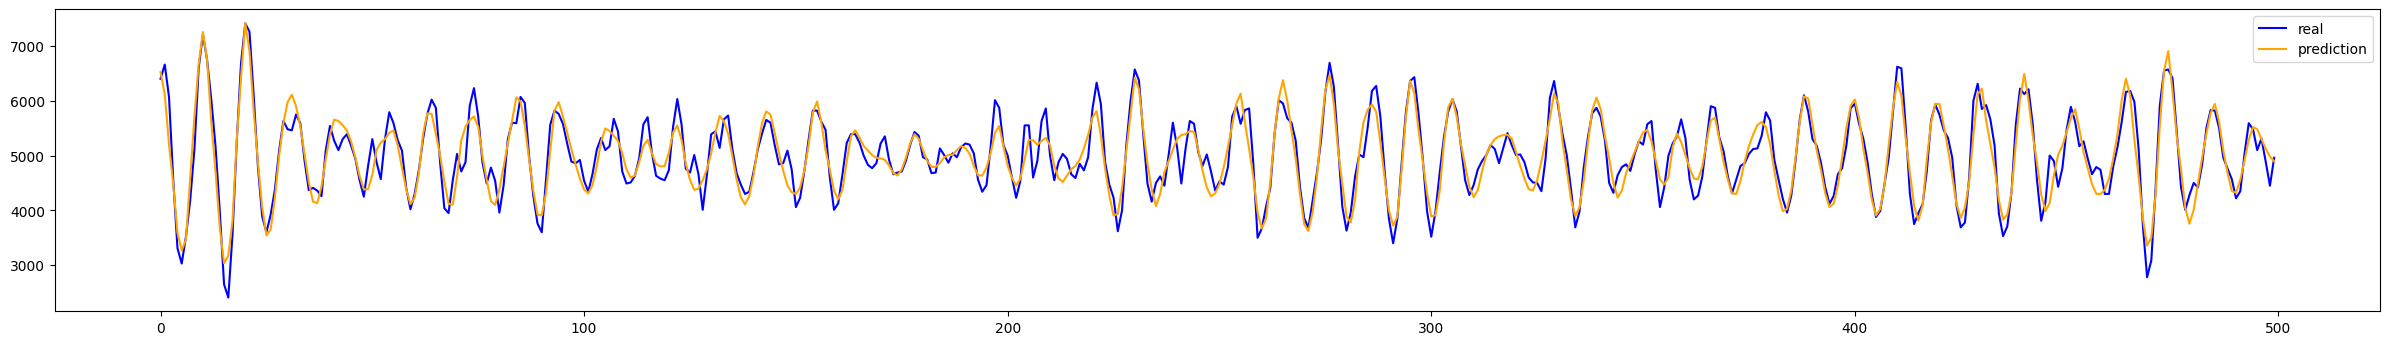

MAE: 225.15592626953125
MAE(sklearn): 225.15592626953125
MAPE(sklearn): 0.046334500601539576
MSE: 80092.5685621773
MSE(sklearn): 80092.5685621773
RMSE(sklearn): 283.0063048099411
Acc: 0.9562499430086079


In [15]:
fan_force150_real1,fan_force150_pre1 = FanGuiHua_force1(valid50_y_Force1,N_pre50_Y_Force1)

np.savetxt('force150_步长1.csv',np.hstack((fan_force150_real1,fan_force150_pre1)),delimiter=',')

In [16]:
# 输入50步长输出1步长Force2
force250_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[350:,:], 4, 50)
force250_x1,force250_y1 = split_sequence(force250_scaled1, 50)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [17]:
train_force250_x1, train_force250_y1, valid_force250_x1, valid_force250_y1 = split_train_valid(force250_x1,force250_y1, 6900, 7500, 8000)
train50_x_Force2, valid50_x_Force2 = np.hstack((pretrain_heave50_Y1, pretrain_surge50_Y1, pretrain_pitch50_Y1)), np.hstack((pre_heave50_Y1, pre_surge50_Y1, pre_pitch50_Y1))
train50_y_Force2, valid50_y_Force2 = train_force250_y1, valid_force250_y1

In [18]:
N_model50_Force2, N_history50_Force2, N_pre50_train_Y_Force2, N_pre50_Y_Force2 = Model_NN(train50_x_Force2, train50_y_Force2, valid50_x_Force2, valid50_y_Force2, lr=0.01, epochs=1000, batch_size=256)

Train on 600 samples, validate on 500 samples
Epoch 1/1000
 - 0s - loss: 0.0777 - val_loss: 0.0755
Epoch 2/1000
 - 0s - loss: 0.0745 - val_loss: 0.0588
Epoch 3/1000
 - 0s - loss: 0.0631 - val_loss: 0.0494
Epoch 4/1000
 - 0s - loss: 0.0569 - val_loss: 0.0512
Epoch 5/1000
 - 0s - loss: 0.0574 - val_loss: 0.0487
Epoch 6/1000
 - 0s - loss: 0.0539 - val_loss: 0.0472
Epoch 7/1000
 - 0s - loss: 0.0523 - val_loss: 0.0458
Epoch 8/1000
 - 0s - loss: 0.0505 - val_loss: 0.0437
Epoch 9/1000
 - 0s - loss: 0.0486 - val_loss: 0.0413
Epoch 10/1000
 - 0s - loss: 0.0460 - val_loss: 0.0415
Epoch 11/1000
 - 0s - loss: 0.0450 - val_loss: 0.0408
Epoch 12/1000
 - 0s - loss: 0.0437 - val_loss: 0.0395
Epoch 13/1000
 - 0s - loss: 0.0419 - val_loss: 0.0401
Epoch 14/1000
 - 0s - loss: 0.0410 - val_loss: 0.0399
Epoch 15/1000
 - 0s - loss: 0.0404 - val_loss: 0.0414
Epoch 16/1000
 - 0s - loss: 0.0405 - val_loss: 0.0417
Epoch 17/1000
 - 0s - loss: 0.0404 - val_loss: 0.0432
Epoch 18/1000
 - 0s - loss: 0.0406 - val_loss

Epoch 151/1000
 - 0s - loss: 0.0403 - val_loss: 0.0416
Epoch 152/1000
 - 0s - loss: 0.0403 - val_loss: 0.0416
Epoch 153/1000
 - 0s - loss: 0.0403 - val_loss: 0.0416
Epoch 154/1000
 - 0s - loss: 0.0403 - val_loss: 0.0416
Epoch 155/1000
 - 0s - loss: 0.0403 - val_loss: 0.0416
Epoch 156/1000
 - 0s - loss: 0.0403 - val_loss: 0.0416
Epoch 157/1000
 - 0s - loss: 0.0403 - val_loss: 0.0416
Epoch 158/1000
 - 0s - loss: 0.0403 - val_loss: 0.0416
Epoch 159/1000
 - 0s - loss: 0.0403 - val_loss: 0.0416
Epoch 160/1000
 - 0s - loss: 0.0403 - val_loss: 0.0416
Epoch 161/1000
 - 0s - loss: 0.0403 - val_loss: 0.0416
Epoch 162/1000
 - 0s - loss: 0.0403 - val_loss: 0.0416
Epoch 163/1000
 - 0s - loss: 0.0403 - val_loss: 0.0416
Epoch 164/1000
 - 0s - loss: 0.0403 - val_loss: 0.0416
Epoch 165/1000
 - 0s - loss: 0.0403 - val_loss: 0.0416
Epoch 166/1000
 - 0s - loss: 0.0403 - val_loss: 0.0416
Epoch 167/1000
 - 0s - loss: 0.0403 - val_loss: 0.0416
Epoch 168/1000
 - 0s - loss: 0.0403 - val_loss: 0.0416
Epoch 169/

Epoch 300/1000
 - 0s - loss: 0.0392 - val_loss: 0.0392
Epoch 301/1000
 - 0s - loss: 0.0392 - val_loss: 0.0392
Epoch 302/1000
 - 0s - loss: 0.0392 - val_loss: 0.0391
Epoch 303/1000
 - 0s - loss: 0.0392 - val_loss: 0.0391
Epoch 304/1000
 - 0s - loss: 0.0392 - val_loss: 0.0391
Epoch 305/1000
 - 0s - loss: 0.0392 - val_loss: 0.0391
Epoch 306/1000
 - 0s - loss: 0.0392 - val_loss: 0.0391
Epoch 307/1000
 - 0s - loss: 0.0392 - val_loss: 0.0391
Epoch 308/1000
 - 0s - loss: 0.0392 - val_loss: 0.0391
Epoch 309/1000
 - 0s - loss: 0.0392 - val_loss: 0.0390
Epoch 310/1000
 - 0s - loss: 0.0392 - val_loss: 0.0390
Epoch 311/1000
 - 0s - loss: 0.0392 - val_loss: 0.0390
Epoch 312/1000
 - 0s - loss: 0.0391 - val_loss: 0.0390
Epoch 313/1000
 - 0s - loss: 0.0391 - val_loss: 0.0390
Epoch 314/1000
 - 0s - loss: 0.0391 - val_loss: 0.0390
Epoch 315/1000
 - 0s - loss: 0.0391 - val_loss: 0.0389
Epoch 316/1000
 - 0s - loss: 0.0391 - val_loss: 0.0389
Epoch 317/1000
 - 0s - loss: 0.0391 - val_loss: 0.0389
Epoch 318/

Epoch 449/1000
 - 0s - loss: 0.0385 - val_loss: 0.0376
Epoch 450/1000
 - 0s - loss: 0.0385 - val_loss: 0.0376
Epoch 451/1000
 - 0s - loss: 0.0385 - val_loss: 0.0376
Epoch 452/1000
 - 0s - loss: 0.0385 - val_loss: 0.0376
Epoch 453/1000
 - 0s - loss: 0.0385 - val_loss: 0.0377
Epoch 454/1000
 - 0s - loss: 0.0385 - val_loss: 0.0377
Epoch 455/1000
 - 0s - loss: 0.0385 - val_loss: 0.0377
Epoch 456/1000
 - 0s - loss: 0.0384 - val_loss: 0.0377
Epoch 457/1000
 - 0s - loss: 0.0384 - val_loss: 0.0377
Epoch 458/1000
 - 0s - loss: 0.0384 - val_loss: 0.0377
Epoch 459/1000
 - 0s - loss: 0.0384 - val_loss: 0.0377
Epoch 460/1000
 - 0s - loss: 0.0384 - val_loss: 0.0377
Epoch 461/1000
 - 0s - loss: 0.0384 - val_loss: 0.0377
Epoch 462/1000
 - 0s - loss: 0.0384 - val_loss: 0.0377
Epoch 463/1000
 - 0s - loss: 0.0384 - val_loss: 0.0377
Epoch 464/1000
 - 0s - loss: 0.0384 - val_loss: 0.0377
Epoch 465/1000
 - 0s - loss: 0.0384 - val_loss: 0.0377
Epoch 466/1000
 - 0s - loss: 0.0384 - val_loss: 0.0377
Epoch 467/

Epoch 598/1000
 - 0s - loss: 0.0379 - val_loss: 0.0385
Epoch 599/1000
 - 0s - loss: 0.0378 - val_loss: 0.0385
Epoch 600/1000
 - 0s - loss: 0.0378 - val_loss: 0.0386
Epoch 601/1000
 - 0s - loss: 0.0378 - val_loss: 0.0386
Epoch 602/1000
 - 0s - loss: 0.0378 - val_loss: 0.0386
Epoch 603/1000
 - 0s - loss: 0.0379 - val_loss: 0.0388
Epoch 604/1000
 - 0s - loss: 0.0380 - val_loss: 0.0390
Epoch 605/1000
 - 0s - loss: 0.0381 - val_loss: 0.0390
Epoch 606/1000
 - 0s - loss: 0.0381 - val_loss: 0.0388
Epoch 607/1000
 - 0s - loss: 0.0379 - val_loss: 0.0386
Epoch 608/1000
 - 0s - loss: 0.0378 - val_loss: 0.0387
Epoch 609/1000
 - 0s - loss: 0.0378 - val_loss: 0.0388
Epoch 610/1000
 - 0s - loss: 0.0379 - val_loss: 0.0387
Epoch 611/1000
 - 0s - loss: 0.0378 - val_loss: 0.0388
Epoch 612/1000
 - 0s - loss: 0.0380 - val_loss: 0.0393
Epoch 613/1000
 - 0s - loss: 0.0383 - val_loss: 0.0396
Epoch 614/1000
 - 0s - loss: 0.0383 - val_loss: 0.0390
Epoch 615/1000
 - 0s - loss: 0.0379 - val_loss: 0.0386
Epoch 616/

Epoch 747/1000
 - 0s - loss: 0.0375 - val_loss: 0.0399
Epoch 748/1000
 - 0s - loss: 0.0375 - val_loss: 0.0399
Epoch 749/1000
 - 0s - loss: 0.0375 - val_loss: 0.0399
Epoch 750/1000
 - 0s - loss: 0.0375 - val_loss: 0.0399
Epoch 751/1000
 - 0s - loss: 0.0375 - val_loss: 0.0399
Epoch 752/1000
 - 0s - loss: 0.0375 - val_loss: 0.0399
Epoch 753/1000
 - 0s - loss: 0.0375 - val_loss: 0.0399
Epoch 754/1000
 - 0s - loss: 0.0375 - val_loss: 0.0399
Epoch 755/1000
 - 0s - loss: 0.0375 - val_loss: 0.0399
Epoch 756/1000
 - 0s - loss: 0.0375 - val_loss: 0.0399
Epoch 757/1000
 - 0s - loss: 0.0375 - val_loss: 0.0399
Epoch 758/1000
 - 0s - loss: 0.0375 - val_loss: 0.0399
Epoch 759/1000
 - 0s - loss: 0.0375 - val_loss: 0.0399
Epoch 760/1000
 - 0s - loss: 0.0375 - val_loss: 0.0399
Epoch 761/1000
 - 0s - loss: 0.0375 - val_loss: 0.0399
Epoch 762/1000
 - 0s - loss: 0.0375 - val_loss: 0.0399
Epoch 763/1000
 - 0s - loss: 0.0375 - val_loss: 0.0399
Epoch 764/1000
 - 0s - loss: 0.0375 - val_loss: 0.0399
Epoch 765/

Epoch 896/1000
 - 0s - loss: 0.0372 - val_loss: 0.0401
Epoch 897/1000
 - 0s - loss: 0.0372 - val_loss: 0.0401
Epoch 898/1000
 - 0s - loss: 0.0371 - val_loss: 0.0401
Epoch 899/1000
 - 0s - loss: 0.0372 - val_loss: 0.0402
Epoch 900/1000
 - 0s - loss: 0.0371 - val_loss: 0.0401
Epoch 901/1000
 - 0s - loss: 0.0372 - val_loss: 0.0402
Epoch 902/1000
 - 0s - loss: 0.0371 - val_loss: 0.0402
Epoch 903/1000
 - 0s - loss: 0.0371 - val_loss: 0.0402
Epoch 904/1000
 - 0s - loss: 0.0371 - val_loss: 0.0402
Epoch 905/1000
 - 0s - loss: 0.0371 - val_loss: 0.0402
Epoch 906/1000
 - 0s - loss: 0.0371 - val_loss: 0.0402
Epoch 907/1000
 - 0s - loss: 0.0371 - val_loss: 0.0402
Epoch 908/1000
 - 0s - loss: 0.0371 - val_loss: 0.0402
Epoch 909/1000
 - 0s - loss: 0.0371 - val_loss: 0.0402
Epoch 910/1000
 - 0s - loss: 0.0371 - val_loss: 0.0402
Epoch 911/1000
 - 0s - loss: 0.0371 - val_loss: 0.0402
Epoch 912/1000
 - 0s - loss: 0.0371 - val_loss: 0.0402
Epoch 913/1000
 - 0s - loss: 0.0371 - val_loss: 0.0402
Epoch 914/

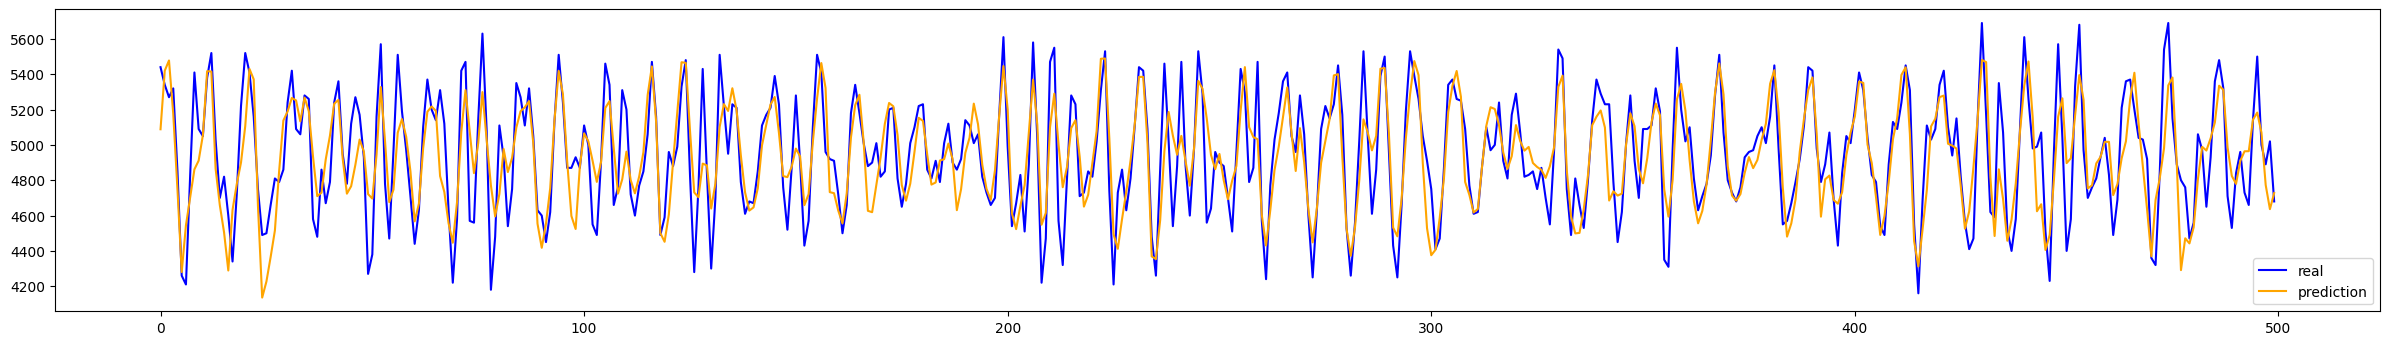

MAE: 158.7207373046875
MAE(sklearn): 158.7207373046875
MAPE(sklearn): 0.03231284885809748
MSE: 41356.82372977209
MSE(sklearn): 41356.82372977209
RMSE(sklearn): 203.36377192059575
Acc: 0.8427372179898169


In [19]:
fan_force250_real1,fan_force250_pre1 = FanGuiHua_force2(valid50_y_Force2,N_pre50_Y_Force2)

np.savetxt('force250_步长1.csv',np.hstack((fan_force250_real1,fan_force250_pre1)),delimiter=',')

#### 系泊缆力联合预测（时间窗50输出；步长2）

In [20]:
# 未来运动预测模型建立
train_heave50_x2, train_heave50_y2, valid_heave50_x2, valid_heave50_y2 = split_train_valid(heave50_x2,heave50_y2, 6900, 7500, 8000)
heave50_model2, heave50_history2, pre_heave50_Y2 = Model_LSTM(train_heave50_x2, train_heave50_y2, valid_heave50_x2, valid_heave50_y2, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x2, train_surge50_y2, valid_surge50_x2, valid_surge50_y2 = split_train_valid(surge50_x2,surge50_y2, 6600, 7500, 8000)
surge50_model2, surge50_history2, pre_surge50_Y2 = Model_LSTM(train_surge50_x2, train_surge50_y2, valid_surge50_x2, valid_surge50_y2, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x2, train_pitch50_y2, valid_pitch50_x2, valid_pitch50_y2 = split_train_valid(pitch50_x2,pitch50_y2, 6900, 7500, 8000)
pitch50_model2, pitch50_history2, pre_pitch50_Y2 = Model_LSTM(train_pitch50_x2, train_pitch50_y2, valid_pitch50_x2, valid_pitch50_y2, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Train on 600 samples, validate on 500 samples
Epoch 1/30
 - 0s - loss: 0.0670 - val_loss: 0.0817
Epoch 2/30
 - 0s - loss: 0.0599 - val_loss: 0.0738
Epoch 3/30
 - 0s - loss: 0.0540 - val_loss: 0.0662
Epoch 4/30
 - 0s - loss: 0.0482 - val_loss: 0.0579
Epoch 5/30
 - 0s - loss: 0.0417 - val_loss: 0.0482
Epoch 6/30
 - 0s - loss: 0.0339 - val_loss: 0.0362
Epoch 7/30
 - 0s - loss: 0.0244 - val_loss: 0.0223
Epoch 8/30
 - 0s - loss: 0.0150 - val_loss: 0.0137
Epoch 9/30
 - 0s - loss: 0.0125 - val_loss: 0.0124
Epoch 10/30
 - 0s - loss: 0.0109 - val_loss: 0.0117
Epoch 11/30
 - 0s - loss: 0.0100 - val_loss: 0.0118
Epoch 12/30
 - 0s - loss: 0.0093 - val_loss: 0.0101
Epoch 13/30
 - 0s - loss: 0.0084 - val_loss: 0.0091
Epoch 14/30
 - 0s - loss: 0.0083 - val_loss: 0.0096
Epoch 15/30
 - 0s - loss: 0.0078 - val_loss: 0.0084
Epoch 16/30
 - 0s - loss: 0.0071 - val_loss: 0.0077
Epoch 17/30
 - 0s - loss: 0.0067 - val_loss: 0.0073
Epoch 18/30
 - 0s - loss: 0.0065 - val_loss: 0.0069
Epoch 19/30
 - 0s - loss: 0

In [21]:
pretrain_heave50_Y2 = heave50_model2.predict(train_heave50_x2)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y2 = surge50_model2.predict(train_surge50_x2[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y2 = pitch50_model2.predict(train_pitch50_x2)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y2.shape)
print(pretrain_surge50_Y2.shape)
print(pretrain_pitch50_Y2.shape)

(600, 1)
(600, 1)
(600, 1)


In [22]:
# 输入50步长输出2步长Force1
force150_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[349:,:], 4, 51)
force150_x2,force150_y2 = split_sequence(force150_scaled2, 50)
# print(force150_x2.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [23]:
train_force150_x2, train_force150_y2, valid_force150_x2, valid_force150_y2 = split_train_valid(force150_x2,force150_y2, 6900, 7500, 8000)
train50_x2_Force1, valid50_x2_Force1 = np.hstack((pretrain_heave50_Y2, pretrain_surge50_Y2, pretrain_pitch50_Y2)), np.hstack((pre_heave50_Y2, pre_surge50_Y2, pre_pitch50_Y2))
train50_y2_Force1, valid50_y2_Force1 = train_force150_y2, valid_force150_y2

In [24]:
N_model50_2_Force1, N_history50_2_Force1, N_pre50_train_Y2_Force1, N_pre50_Y2_Force1 = Model_NN(train50_x2_Force1, train50_y2_Force1, valid50_x2_Force1, valid50_y2_Force1, lr=0.01, epochs=1000, batch_size=256)

Train on 600 samples, validate on 500 samples
Epoch 1/1000
 - 0s - loss: 0.0238 - val_loss: 0.0199
Epoch 2/1000
 - 0s - loss: 0.0175 - val_loss: 0.0168
Epoch 3/1000
 - 0s - loss: 0.0151 - val_loss: 0.0142
Epoch 4/1000
 - 0s - loss: 0.0127 - val_loss: 0.0115
Epoch 5/1000
 - 0s - loss: 0.0122 - val_loss: 0.0126
Epoch 6/1000
 - 0s - loss: 0.0124 - val_loss: 0.0109
Epoch 7/1000
 - 0s - loss: 0.0108 - val_loss: 0.0119
Epoch 8/1000
 - 0s - loss: 0.0116 - val_loss: 0.0119
Epoch 9/1000
 - 0s - loss: 0.0114 - val_loss: 0.0112
Epoch 10/1000
 - 0s - loss: 0.0112 - val_loss: 0.0109
Epoch 11/1000
 - 0s - loss: 0.0110 - val_loss: 0.0109
Epoch 12/1000
 - 0s - loss: 0.0109 - val_loss: 0.0112
Epoch 13/1000
 - 0s - loss: 0.0110 - val_loss: 0.0110
Epoch 14/1000
 - 0s - loss: 0.0109 - val_loss: 0.0109
Epoch 15/1000
 - 0s - loss: 0.0109 - val_loss: 0.0109
Epoch 16/1000
 - 0s - loss: 0.0109 - val_loss: 0.0110
Epoch 17/1000
 - 0s - loss: 0.0109 - val_loss: 0.0109
Epoch 18/1000
 - 0s - loss: 0.0109 - val_loss

Epoch 151/1000
 - 0s - loss: 0.0108 - val_loss: 0.0109
Epoch 152/1000
 - 0s - loss: 0.0108 - val_loss: 0.0109
Epoch 153/1000
 - 0s - loss: 0.0108 - val_loss: 0.0109
Epoch 154/1000
 - 0s - loss: 0.0108 - val_loss: 0.0109
Epoch 155/1000
 - 0s - loss: 0.0108 - val_loss: 0.0109
Epoch 156/1000
 - 0s - loss: 0.0108 - val_loss: 0.0109
Epoch 157/1000
 - 0s - loss: 0.0108 - val_loss: 0.0109
Epoch 158/1000
 - 0s - loss: 0.0108 - val_loss: 0.0109
Epoch 159/1000
 - 0s - loss: 0.0108 - val_loss: 0.0109
Epoch 160/1000
 - 0s - loss: 0.0108 - val_loss: 0.0109
Epoch 161/1000
 - 0s - loss: 0.0108 - val_loss: 0.0109
Epoch 162/1000
 - 0s - loss: 0.0108 - val_loss: 0.0109
Epoch 163/1000
 - 0s - loss: 0.0108 - val_loss: 0.0109
Epoch 164/1000
 - 0s - loss: 0.0108 - val_loss: 0.0109
Epoch 165/1000
 - 0s - loss: 0.0108 - val_loss: 0.0109
Epoch 166/1000
 - 0s - loss: 0.0108 - val_loss: 0.0109
Epoch 167/1000
 - 0s - loss: 0.0108 - val_loss: 0.0109
Epoch 168/1000
 - 0s - loss: 0.0108 - val_loss: 0.0109
Epoch 169/

Epoch 300/1000
 - 0s - loss: 0.0104 - val_loss: 0.0109
Epoch 301/1000
 - 0s - loss: 0.0104 - val_loss: 0.0109
Epoch 302/1000
 - 0s - loss: 0.0104 - val_loss: 0.0109
Epoch 303/1000
 - 0s - loss: 0.0104 - val_loss: 0.0109
Epoch 304/1000
 - 0s - loss: 0.0104 - val_loss: 0.0109
Epoch 305/1000
 - 0s - loss: 0.0104 - val_loss: 0.0109
Epoch 306/1000
 - 0s - loss: 0.0104 - val_loss: 0.0109
Epoch 307/1000
 - 0s - loss: 0.0104 - val_loss: 0.0109
Epoch 308/1000
 - 0s - loss: 0.0104 - val_loss: 0.0109
Epoch 309/1000
 - 0s - loss: 0.0104 - val_loss: 0.0109
Epoch 310/1000
 - 0s - loss: 0.0104 - val_loss: 0.0109
Epoch 311/1000
 - 0s - loss: 0.0104 - val_loss: 0.0109
Epoch 312/1000
 - 0s - loss: 0.0104 - val_loss: 0.0109
Epoch 313/1000
 - 0s - loss: 0.0104 - val_loss: 0.0109
Epoch 314/1000
 - 0s - loss: 0.0104 - val_loss: 0.0109
Epoch 315/1000
 - 0s - loss: 0.0104 - val_loss: 0.0109
Epoch 316/1000
 - 0s - loss: 0.0104 - val_loss: 0.0109
Epoch 317/1000
 - 0s - loss: 0.0104 - val_loss: 0.0109
Epoch 318/

Epoch 449/1000
 - 0s - loss: 0.0102 - val_loss: 0.0110
Epoch 450/1000
 - 0s - loss: 0.0102 - val_loss: 0.0110
Epoch 451/1000
 - 0s - loss: 0.0102 - val_loss: 0.0110
Epoch 452/1000
 - 0s - loss: 0.0102 - val_loss: 0.0110
Epoch 453/1000
 - 0s - loss: 0.0102 - val_loss: 0.0110
Epoch 454/1000
 - 0s - loss: 0.0102 - val_loss: 0.0110
Epoch 455/1000
 - 0s - loss: 0.0102 - val_loss: 0.0110
Epoch 456/1000
 - 0s - loss: 0.0102 - val_loss: 0.0110
Epoch 457/1000
 - 0s - loss: 0.0102 - val_loss: 0.0110
Epoch 458/1000
 - 0s - loss: 0.0102 - val_loss: 0.0110
Epoch 459/1000
 - 0s - loss: 0.0102 - val_loss: 0.0110
Epoch 460/1000
 - 0s - loss: 0.0102 - val_loss: 0.0109
Epoch 461/1000
 - 0s - loss: 0.0101 - val_loss: 0.0109
Epoch 462/1000
 - 0s - loss: 0.0101 - val_loss: 0.0109
Epoch 463/1000
 - 0s - loss: 0.0101 - val_loss: 0.0109
Epoch 464/1000
 - 0s - loss: 0.0101 - val_loss: 0.0109
Epoch 465/1000
 - 0s - loss: 0.0101 - val_loss: 0.0109
Epoch 466/1000
 - 0s - loss: 0.0101 - val_loss: 0.0109
Epoch 467/

Epoch 598/1000
 - 0s - loss: 0.0100 - val_loss: 0.0109
Epoch 599/1000
 - 0s - loss: 0.0100 - val_loss: 0.0109
Epoch 600/1000
 - 0s - loss: 0.0100 - val_loss: 0.0109
Epoch 601/1000
 - 0s - loss: 0.0100 - val_loss: 0.0109
Epoch 602/1000
 - 0s - loss: 0.0100 - val_loss: 0.0109
Epoch 603/1000
 - 0s - loss: 0.0100 - val_loss: 0.0109
Epoch 604/1000
 - 0s - loss: 0.0100 - val_loss: 0.0109
Epoch 605/1000
 - 0s - loss: 0.0100 - val_loss: 0.0109
Epoch 606/1000
 - 0s - loss: 0.0100 - val_loss: 0.0109
Epoch 607/1000
 - 0s - loss: 0.0100 - val_loss: 0.0109
Epoch 608/1000
 - 0s - loss: 0.0100 - val_loss: 0.0109
Epoch 609/1000
 - 0s - loss: 0.0100 - val_loss: 0.0109
Epoch 610/1000
 - 0s - loss: 0.0100 - val_loss: 0.0109
Epoch 611/1000
 - 0s - loss: 0.0100 - val_loss: 0.0109
Epoch 612/1000
 - 0s - loss: 0.0100 - val_loss: 0.0109
Epoch 613/1000
 - 0s - loss: 0.0100 - val_loss: 0.0109
Epoch 614/1000
 - 0s - loss: 0.0100 - val_loss: 0.0109
Epoch 615/1000
 - 0s - loss: 0.0100 - val_loss: 0.0109
Epoch 616/

Epoch 747/1000
 - 0s - loss: 0.0099 - val_loss: 0.0108
Epoch 748/1000
 - 0s - loss: 0.0099 - val_loss: 0.0108
Epoch 749/1000
 - 0s - loss: 0.0099 - val_loss: 0.0108
Epoch 750/1000
 - 0s - loss: 0.0099 - val_loss: 0.0108
Epoch 751/1000
 - 0s - loss: 0.0099 - val_loss: 0.0108
Epoch 752/1000
 - 0s - loss: 0.0099 - val_loss: 0.0108
Epoch 753/1000
 - 0s - loss: 0.0099 - val_loss: 0.0108
Epoch 754/1000
 - 0s - loss: 0.0099 - val_loss: 0.0108
Epoch 755/1000
 - 0s - loss: 0.0099 - val_loss: 0.0108
Epoch 756/1000
 - 0s - loss: 0.0099 - val_loss: 0.0108
Epoch 757/1000
 - 0s - loss: 0.0099 - val_loss: 0.0108
Epoch 758/1000
 - 0s - loss: 0.0099 - val_loss: 0.0108
Epoch 759/1000
 - 0s - loss: 0.0099 - val_loss: 0.0108
Epoch 760/1000
 - 0s - loss: 0.0099 - val_loss: 0.0108
Epoch 761/1000
 - 0s - loss: 0.0099 - val_loss: 0.0108
Epoch 762/1000
 - 0s - loss: 0.0099 - val_loss: 0.0108
Epoch 763/1000
 - 0s - loss: 0.0099 - val_loss: 0.0108
Epoch 764/1000
 - 0s - loss: 0.0099 - val_loss: 0.0108
Epoch 765/

Epoch 896/1000
 - 0s - loss: 0.0098 - val_loss: 0.0108
Epoch 897/1000
 - 0s - loss: 0.0098 - val_loss: 0.0108
Epoch 898/1000
 - 0s - loss: 0.0098 - val_loss: 0.0108
Epoch 899/1000
 - 0s - loss: 0.0098 - val_loss: 0.0108
Epoch 900/1000
 - 0s - loss: 0.0098 - val_loss: 0.0108
Epoch 901/1000
 - 0s - loss: 0.0098 - val_loss: 0.0108
Epoch 902/1000
 - 0s - loss: 0.0098 - val_loss: 0.0108
Epoch 903/1000
 - 0s - loss: 0.0098 - val_loss: 0.0108
Epoch 904/1000
 - 0s - loss: 0.0098 - val_loss: 0.0108
Epoch 905/1000
 - 0s - loss: 0.0098 - val_loss: 0.0108
Epoch 906/1000
 - 0s - loss: 0.0098 - val_loss: 0.0108
Epoch 907/1000
 - 0s - loss: 0.0098 - val_loss: 0.0108
Epoch 908/1000
 - 0s - loss: 0.0098 - val_loss: 0.0108
Epoch 909/1000
 - 0s - loss: 0.0098 - val_loss: 0.0108
Epoch 910/1000
 - 0s - loss: 0.0098 - val_loss: 0.0108
Epoch 911/1000
 - 0s - loss: 0.0098 - val_loss: 0.0108
Epoch 912/1000
 - 0s - loss: 0.0098 - val_loss: 0.0108
Epoch 913/1000
 - 0s - loss: 0.0098 - val_loss: 0.0108
Epoch 914/

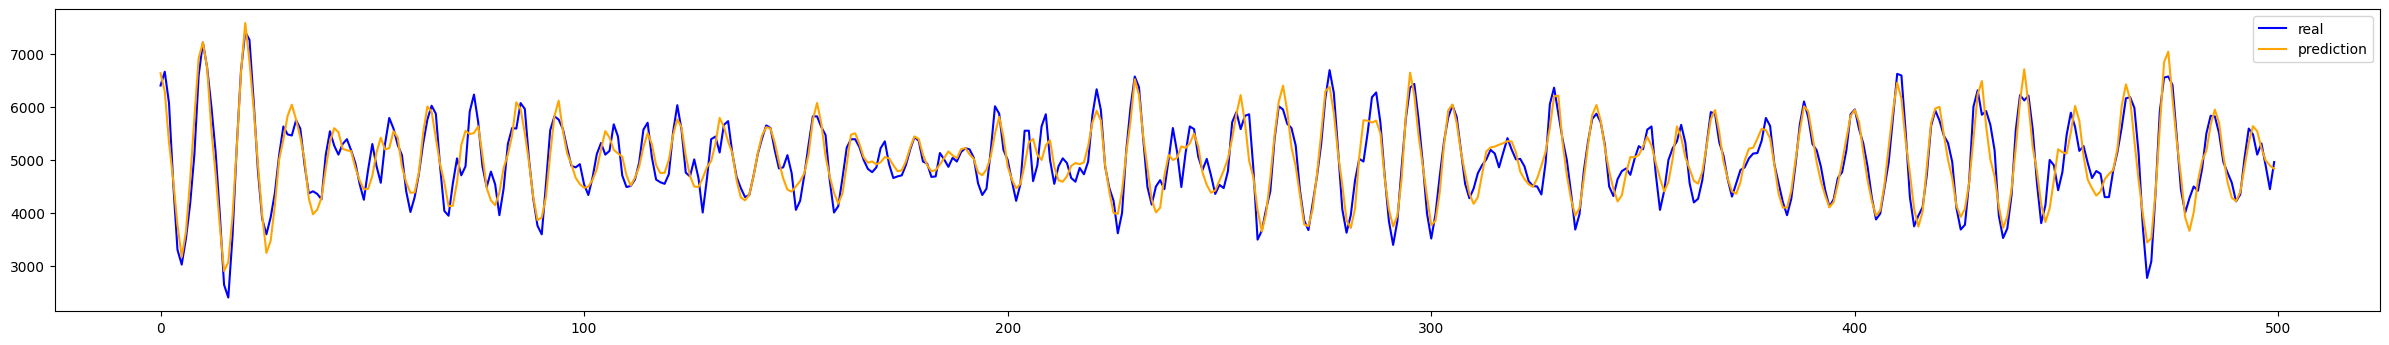

MAE: 231.323021484375
MAE(sklearn): 231.323021484375
MAPE(sklearn): 0.047618002138247184
MSE: 86117.50460793875
MSE(sklearn): 86117.50460793875
RMSE(sklearn): 293.45784127867284
Acc: 0.9441335141454519


In [25]:
fan_force150_real2,fan_force150_pre2 = FanGuiHua_force1(valid50_y2_Force1,N_pre50_Y2_Force1)

np.savetxt('force150_步长2.csv',np.hstack((fan_force150_real2,fan_force150_pre2)),delimiter=',')

In [26]:
# 输入50步长输出2步长Force2
force250_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[349:,:], 4, 51)
force250_x2,force250_y2 = split_sequence(force250_scaled2, 50)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [27]:
train_force250_x2, train_force250_y2, valid_force250_x2, valid_force250_y2 = split_train_valid(force250_x2,force250_y2, 6900, 7500, 8000)
train50_x2_Force2, valid50_x2_Force2 = np.hstack((pretrain_heave50_Y2, pretrain_surge50_Y2, pretrain_pitch50_Y2)), np.hstack((pre_heave50_Y2, pre_surge50_Y2, pre_pitch50_Y2))
train50_y2_Force2, valid50_y2_Force2 = train_force250_y2, valid_force250_y2

In [28]:
N_model50_2_Force2, N_history50_2_Force2, N_pre50_train_Y2_Force2, N_pre50_Y2_Force2 = Model_NN(train50_x2_Force2, train50_y2_Force2, valid50_x2_Force2, valid50_y2_Force2,lr=0.01, epochs=1000, batch_size=256)

Train on 600 samples, validate on 500 samples
Epoch 1/1000
 - 0s - loss: 0.0920 - val_loss: 0.0865
Epoch 2/1000
 - 0s - loss: 0.0876 - val_loss: 0.0629
Epoch 3/1000
 - 0s - loss: 0.0678 - val_loss: 0.0577
Epoch 4/1000
 - 0s - loss: 0.0667 - val_loss: 0.0588
Epoch 5/1000
 - 0s - loss: 0.0647 - val_loss: 0.0527
Epoch 6/1000
 - 0s - loss: 0.0598 - val_loss: 0.0540
Epoch 7/1000
 - 0s - loss: 0.0603 - val_loss: 0.0546
Epoch 8/1000
 - 0s - loss: 0.0592 - val_loss: 0.0501
Epoch 9/1000
 - 0s - loss: 0.0556 - val_loss: 0.0489
Epoch 10/1000
 - 0s - loss: 0.0542 - val_loss: 0.0480
Epoch 11/1000
 - 0s - loss: 0.0519 - val_loss: 0.0478
Epoch 12/1000
 - 0s - loss: 0.0507 - val_loss: 0.0485
Epoch 13/1000
 - 0s - loss: 0.0498 - val_loss: 0.0475
Epoch 14/1000
 - 0s - loss: 0.0481 - val_loss: 0.0491
Epoch 15/1000
 - 0s - loss: 0.0475 - val_loss: 0.0500
Epoch 16/1000
 - 0s - loss: 0.0473 - val_loss: 0.0522
Epoch 17/1000
 - 0s - loss: 0.0477 - val_loss: 0.0535
Epoch 18/1000
 - 0s - loss: 0.0479 - val_loss

Epoch 152/1000
 - 0s - loss: 0.0474 - val_loss: 0.0517
Epoch 153/1000
 - 0s - loss: 0.0474 - val_loss: 0.0517
Epoch 154/1000
 - 0s - loss: 0.0474 - val_loss: 0.0517
Epoch 155/1000
 - 0s - loss: 0.0474 - val_loss: 0.0517
Epoch 156/1000
 - 0s - loss: 0.0474 - val_loss: 0.0517
Epoch 157/1000
 - 0s - loss: 0.0474 - val_loss: 0.0517
Epoch 158/1000
 - 0s - loss: 0.0474 - val_loss: 0.0517
Epoch 159/1000
 - 0s - loss: 0.0474 - val_loss: 0.0517
Epoch 160/1000
 - 0s - loss: 0.0474 - val_loss: 0.0517
Epoch 161/1000
 - 0s - loss: 0.0474 - val_loss: 0.0517
Epoch 162/1000
 - 0s - loss: 0.0474 - val_loss: 0.0517
Epoch 163/1000
 - 0s - loss: 0.0474 - val_loss: 0.0517
Epoch 164/1000
 - 0s - loss: 0.0474 - val_loss: 0.0517
Epoch 165/1000
 - 0s - loss: 0.0474 - val_loss: 0.0517
Epoch 166/1000
 - 0s - loss: 0.0474 - val_loss: 0.0517
Epoch 167/1000
 - 0s - loss: 0.0474 - val_loss: 0.0517
Epoch 168/1000
 - 0s - loss: 0.0474 - val_loss: 0.0517
Epoch 169/1000
 - 0s - loss: 0.0474 - val_loss: 0.0517
Epoch 170/

Epoch 301/1000
 - 0s - loss: 0.0471 - val_loss: 0.0517
Epoch 302/1000
 - 0s - loss: 0.0471 - val_loss: 0.0517
Epoch 303/1000
 - 0s - loss: 0.0471 - val_loss: 0.0517
Epoch 304/1000
 - 0s - loss: 0.0471 - val_loss: 0.0517
Epoch 305/1000
 - 0s - loss: 0.0471 - val_loss: 0.0517
Epoch 306/1000
 - 0s - loss: 0.0470 - val_loss: 0.0517
Epoch 307/1000
 - 0s - loss: 0.0470 - val_loss: 0.0517
Epoch 308/1000
 - 0s - loss: 0.0470 - val_loss: 0.0517
Epoch 309/1000
 - 0s - loss: 0.0470 - val_loss: 0.0517
Epoch 310/1000
 - 0s - loss: 0.0470 - val_loss: 0.0517
Epoch 311/1000
 - 0s - loss: 0.0469 - val_loss: 0.0517
Epoch 312/1000
 - 0s - loss: 0.0469 - val_loss: 0.0517
Epoch 313/1000
 - 0s - loss: 0.0469 - val_loss: 0.0517
Epoch 314/1000
 - 0s - loss: 0.0469 - val_loss: 0.0517
Epoch 315/1000
 - 0s - loss: 0.0468 - val_loss: 0.0517
Epoch 316/1000
 - 0s - loss: 0.0468 - val_loss: 0.0517
Epoch 317/1000
 - 0s - loss: 0.0468 - val_loss: 0.0517
Epoch 318/1000
 - 0s - loss: 0.0467 - val_loss: 0.0516
Epoch 319/

Epoch 450/1000
 - 0s - loss: 0.0431 - val_loss: 0.0515
Epoch 451/1000
 - 0s - loss: 0.0430 - val_loss: 0.0515
Epoch 452/1000
 - 0s - loss: 0.0430 - val_loss: 0.0515
Epoch 453/1000
 - 0s - loss: 0.0430 - val_loss: 0.0515
Epoch 454/1000
 - 0s - loss: 0.0430 - val_loss: 0.0515
Epoch 455/1000
 - 0s - loss: 0.0430 - val_loss: 0.0515
Epoch 456/1000
 - 0s - loss: 0.0430 - val_loss: 0.0515
Epoch 457/1000
 - 0s - loss: 0.0430 - val_loss: 0.0515
Epoch 458/1000
 - 0s - loss: 0.0430 - val_loss: 0.0515
Epoch 459/1000
 - 0s - loss: 0.0430 - val_loss: 0.0515
Epoch 460/1000
 - 0s - loss: 0.0430 - val_loss: 0.0515
Epoch 461/1000
 - 0s - loss: 0.0430 - val_loss: 0.0515
Epoch 462/1000
 - 0s - loss: 0.0430 - val_loss: 0.0515
Epoch 463/1000
 - 0s - loss: 0.0430 - val_loss: 0.0515
Epoch 464/1000
 - 0s - loss: 0.0430 - val_loss: 0.0516
Epoch 465/1000
 - 0s - loss: 0.0430 - val_loss: 0.0516
Epoch 466/1000
 - 0s - loss: 0.0429 - val_loss: 0.0516
Epoch 467/1000
 - 0s - loss: 0.0429 - val_loss: 0.0516
Epoch 468/

Epoch 599/1000
 - 0s - loss: 0.0422 - val_loss: 0.0532
Epoch 600/1000
 - 0s - loss: 0.0422 - val_loss: 0.0533
Epoch 601/1000
 - 0s - loss: 0.0422 - val_loss: 0.0533
Epoch 602/1000
 - 0s - loss: 0.0422 - val_loss: 0.0533
Epoch 603/1000
 - 0s - loss: 0.0422 - val_loss: 0.0533
Epoch 604/1000
 - 0s - loss: 0.0422 - val_loss: 0.0533
Epoch 605/1000
 - 0s - loss: 0.0422 - val_loss: 0.0533
Epoch 606/1000
 - 0s - loss: 0.0422 - val_loss: 0.0533
Epoch 607/1000
 - 0s - loss: 0.0422 - val_loss: 0.0533
Epoch 608/1000
 - 0s - loss: 0.0422 - val_loss: 0.0533
Epoch 609/1000
 - 0s - loss: 0.0422 - val_loss: 0.0533
Epoch 610/1000
 - 0s - loss: 0.0422 - val_loss: 0.0534
Epoch 611/1000
 - 0s - loss: 0.0422 - val_loss: 0.0534
Epoch 612/1000
 - 0s - loss: 0.0421 - val_loss: 0.0534
Epoch 613/1000
 - 0s - loss: 0.0421 - val_loss: 0.0534
Epoch 614/1000
 - 0s - loss: 0.0421 - val_loss: 0.0534
Epoch 615/1000
 - 0s - loss: 0.0421 - val_loss: 0.0534
Epoch 616/1000
 - 0s - loss: 0.0421 - val_loss: 0.0534
Epoch 617/

Epoch 748/1000
 - 0s - loss: 0.0411 - val_loss: 0.0543
Epoch 749/1000
 - 0s - loss: 0.0411 - val_loss: 0.0544
Epoch 750/1000
 - 0s - loss: 0.0410 - val_loss: 0.0544
Epoch 751/1000
 - 0s - loss: 0.0410 - val_loss: 0.0544
Epoch 752/1000
 - 0s - loss: 0.0410 - val_loss: 0.0544
Epoch 753/1000
 - 0s - loss: 0.0410 - val_loss: 0.0544
Epoch 754/1000
 - 0s - loss: 0.0410 - val_loss: 0.0545
Epoch 755/1000
 - 0s - loss: 0.0410 - val_loss: 0.0545
Epoch 756/1000
 - 0s - loss: 0.0410 - val_loss: 0.0545
Epoch 757/1000
 - 0s - loss: 0.0410 - val_loss: 0.0546
Epoch 758/1000
 - 0s - loss: 0.0410 - val_loss: 0.0546
Epoch 759/1000
 - 0s - loss: 0.0410 - val_loss: 0.0546
Epoch 760/1000
 - 0s - loss: 0.0410 - val_loss: 0.0546
Epoch 761/1000
 - 0s - loss: 0.0410 - val_loss: 0.0546
Epoch 762/1000
 - 0s - loss: 0.0410 - val_loss: 0.0546
Epoch 763/1000
 - 0s - loss: 0.0410 - val_loss: 0.0546
Epoch 764/1000
 - 0s - loss: 0.0411 - val_loss: 0.0547
Epoch 765/1000
 - 0s - loss: 0.0412 - val_loss: 0.0548
Epoch 766/

Epoch 897/1000
 - 0s - loss: 0.0407 - val_loss: 0.0559
Epoch 898/1000
 - 0s - loss: 0.0407 - val_loss: 0.0559
Epoch 899/1000
 - 0s - loss: 0.0407 - val_loss: 0.0559
Epoch 900/1000
 - 0s - loss: 0.0407 - val_loss: 0.0559
Epoch 901/1000
 - 0s - loss: 0.0407 - val_loss: 0.0559
Epoch 902/1000
 - 0s - loss: 0.0407 - val_loss: 0.0559
Epoch 903/1000
 - 0s - loss: 0.0407 - val_loss: 0.0559
Epoch 904/1000
 - 0s - loss: 0.0407 - val_loss: 0.0559
Epoch 905/1000
 - 0s - loss: 0.0407 - val_loss: 0.0559
Epoch 906/1000
 - 0s - loss: 0.0407 - val_loss: 0.0559
Epoch 907/1000
 - 0s - loss: 0.0407 - val_loss: 0.0559
Epoch 908/1000
 - 0s - loss: 0.0406 - val_loss: 0.0559
Epoch 909/1000
 - 0s - loss: 0.0406 - val_loss: 0.0559
Epoch 910/1000
 - 0s - loss: 0.0406 - val_loss: 0.0559
Epoch 911/1000
 - 0s - loss: 0.0406 - val_loss: 0.0559
Epoch 912/1000
 - 0s - loss: 0.0406 - val_loss: 0.0559
Epoch 913/1000
 - 0s - loss: 0.0406 - val_loss: 0.0559
Epoch 914/1000
 - 0s - loss: 0.0406 - val_loss: 0.0559
Epoch 915/

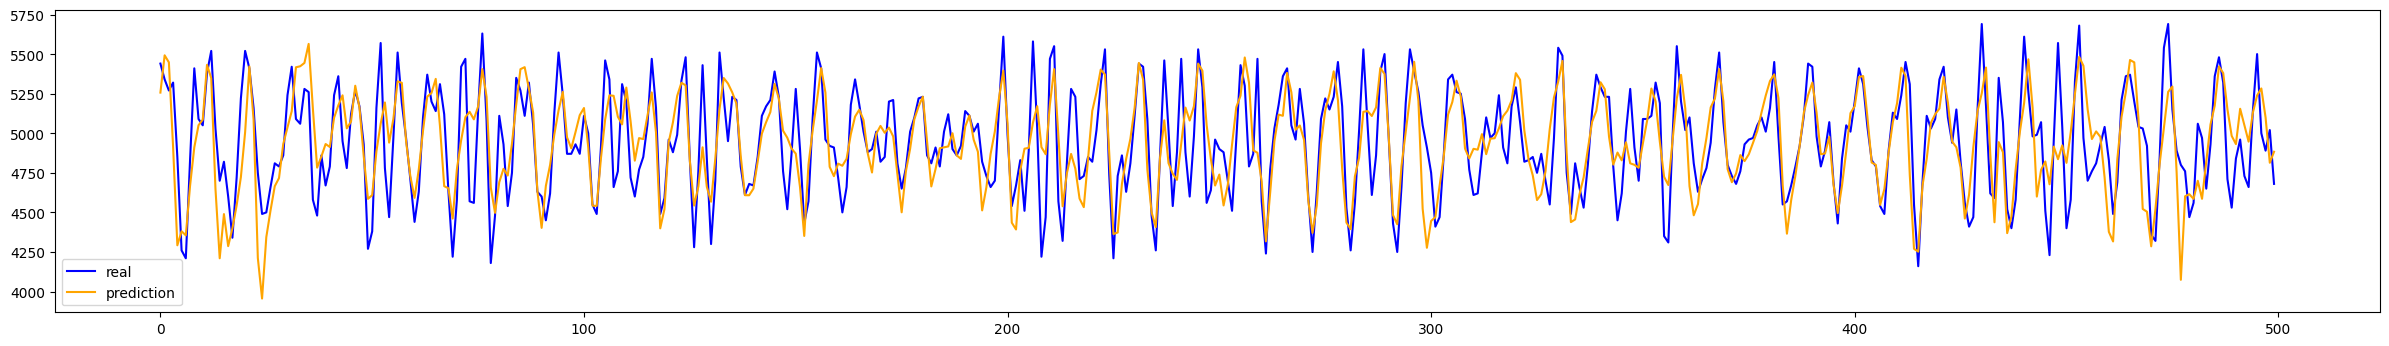

MAE: 185.80535107421875
MAE(sklearn): 185.80535107421875
MAPE(sklearn): 0.03778290910513904
MSE: 56639.58258029759
MSE(sklearn): 56639.58258029759
RMSE(sklearn): 237.99071952556804
Acc: 0.8854859206734876


In [29]:
fan_force250_real2,fan_force250_pre2 = FanGuiHua_force2(valid50_y2_Force2,N_pre50_Y2_Force2)

np.savetxt('force250_步长2.csv',np.hstack((fan_force250_real2,fan_force250_pre2)),delimiter=',')

#### 系泊缆力联合预测（时间窗50输出；步长3）

In [30]:
# 未来运动预测模型建立
train_heave50_x3, train_heave50_y3, valid_heave50_x3, valid_heave50_y3 = split_train_valid(heave50_x3,heave50_y3, 6900, 7500, 8000)
heave50_model3, heave50_history3, pre_heave50_Y3 = Model_LSTM(train_heave50_x3, train_heave50_y3, valid_heave50_x3, valid_heave50_y3, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x3, train_surge50_y3, valid_surge50_x3, valid_surge50_y3 = split_train_valid(surge50_x3,surge50_y3, 6600, 7500, 8000)
surge50_model3, surge50_history3, pre_surge50_Y3 = Model_LSTM(train_surge50_x3, train_surge50_y3, valid_surge50_x3, valid_surge50_y3, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x3, train_pitch50_y3, valid_pitch50_x3, valid_pitch50_y3 = split_train_valid(pitch50_x3,pitch50_y3, 6900, 7500, 8000)
pitch50_model3, pitch50_history3, pre_pitch50_Y3 = Model_LSTM(train_pitch50_x3, train_pitch50_y3, valid_pitch50_x3, valid_pitch50_y3, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Train on 600 samples, validate on 500 samples
Epoch 1/30
 - 0s - loss: 0.0620 - val_loss: 0.0754
Epoch 2/30
 - 0s - loss: 0.0553 - val_loss: 0.0691
Epoch 3/30
 - 0s - loss: 0.0506 - val_loss: 0.0625
Epoch 4/30
 - 0s - loss: 0.0457 - val_loss: 0.0554
Epoch 5/30
 - 0s - loss: 0.0401 - val_loss: 0.0468
Epoch 6/30
 - 0s - loss: 0.0329 - val_loss: 0.0339
Epoch 7/30
 - 0s - loss: 0.0219 - val_loss: 0.0191
Epoch 8/30
 - 0s - loss: 0.0141 - val_loss: 0.0144
Epoch 9/30
 - 0s - loss: 0.0124 - val_loss: 0.0128
Epoch 10/30
 - 0s - loss: 0.0114 - val_loss: 0.0121
Epoch 11/30
 - 0s - loss: 0.0108 - val_loss: 0.0116
Epoch 12/30
 - 0s - loss: 0.0103 - val_loss: 0.0113
Epoch 13/30
 - 0s - loss: 0.0099 - val_loss: 0.0108
Epoch 14/30
 - 0s - loss: 0.0096 - val_loss: 0.0104
Epoch 15/30
 - 0s - loss: 0.0092 - val_loss: 0.0101
Epoch 16/30
 - 0s - loss: 0.0089 - val_loss: 0.0098
Epoch 17/30
 - 0s - loss: 0.0087 - val_loss: 0.0094
Epoch 18/30
 - 0s - loss: 0.0086 - val_loss: 0.0092
Epoch 19/30
 - 0s - loss: 0

In [31]:
pretrain_heave50_Y3 = heave50_model3.predict(train_heave50_x3)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y3 = surge50_model3.predict(train_surge50_x3[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y3 = pitch50_model3.predict(train_pitch50_x3)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y3.shape)
print(pretrain_surge50_Y3.shape)
print(pretrain_pitch50_Y3.shape)

(600, 1)
(600, 1)
(600, 1)


In [32]:
# 输入50步长输出3步长Force1
force150_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[348:,:], 4, 52)
force150_x3,force150_y3 = split_sequence(force150_scaled3, 50)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [33]:
train_force150_x3, train_force150_y3, valid_force150_x3, valid_force150_y3 = split_train_valid(force150_x3,force150_y3, 6900, 7500, 8000)
train50_x3_Force1, valid50_x3_Force1 = np.hstack((pretrain_heave50_Y3, pretrain_surge50_Y3, pretrain_pitch50_Y3)), np.hstack((pre_heave50_Y3, pre_surge50_Y3, pre_pitch50_Y3))
train50_y3_Force1, valid50_y3_Force1 = train_force150_y3, valid_force150_y3

In [34]:
N_model50_3_Force1, N_history50_3_Force1, N_pre50_train_Y3_Force1, N_pre50_Y3_Force1 = Model_NN(train50_x3_Force1, train50_y3_Force1, valid50_x3_Force1, valid50_y3_Force1, lr=0.01, epochs=1000, batch_size=256)

Train on 600 samples, validate on 500 samples
Epoch 1/1000
 - 0s - loss: 0.0452 - val_loss: 0.0288
Epoch 2/1000
 - 0s - loss: 0.0286 - val_loss: 0.0219
Epoch 3/1000
 - 0s - loss: 0.0187 - val_loss: 0.0207
Epoch 4/1000
 - 0s - loss: 0.0187 - val_loss: 0.0234
Epoch 5/1000
 - 0s - loss: 0.0192 - val_loss: 0.0174
Epoch 6/1000
 - 0s - loss: 0.0159 - val_loss: 0.0155
Epoch 7/1000
 - 0s - loss: 0.0158 - val_loss: 0.0156
Epoch 8/1000
 - 0s - loss: 0.0156 - val_loss: 0.0146
Epoch 9/1000
 - 0s - loss: 0.0145 - val_loss: 0.0157
Epoch 10/1000
 - 0s - loss: 0.0150 - val_loss: 0.0166
Epoch 11/1000
 - 0s - loss: 0.0153 - val_loss: 0.0155
Epoch 12/1000
 - 0s - loss: 0.0147 - val_loss: 0.0146
Epoch 13/1000
 - 0s - loss: 0.0145 - val_loss: 0.0144
Epoch 14/1000
 - 0s - loss: 0.0145 - val_loss: 0.0144
Epoch 15/1000
 - 0s - loss: 0.0144 - val_loss: 0.0146
Epoch 16/1000
 - 0s - loss: 0.0143 - val_loss: 0.0150
Epoch 17/1000
 - 0s - loss: 0.0145 - val_loss: 0.0150
Epoch 18/1000
 - 0s - loss: 0.0145 - val_loss

Epoch 151/1000
 - 0s - loss: 0.0144 - val_loss: 0.0146
Epoch 152/1000
 - 0s - loss: 0.0144 - val_loss: 0.0146
Epoch 153/1000
 - 0s - loss: 0.0144 - val_loss: 0.0146
Epoch 154/1000
 - 0s - loss: 0.0144 - val_loss: 0.0146
Epoch 155/1000
 - 0s - loss: 0.0144 - val_loss: 0.0146
Epoch 156/1000
 - 0s - loss: 0.0144 - val_loss: 0.0146
Epoch 157/1000
 - 0s - loss: 0.0144 - val_loss: 0.0146
Epoch 158/1000
 - 0s - loss: 0.0144 - val_loss: 0.0146
Epoch 159/1000
 - 0s - loss: 0.0144 - val_loss: 0.0146
Epoch 160/1000
 - 0s - loss: 0.0144 - val_loss: 0.0146
Epoch 161/1000
 - 0s - loss: 0.0144 - val_loss: 0.0146
Epoch 162/1000
 - 0s - loss: 0.0144 - val_loss: 0.0146
Epoch 163/1000
 - 0s - loss: 0.0144 - val_loss: 0.0146
Epoch 164/1000
 - 0s - loss: 0.0144 - val_loss: 0.0146
Epoch 165/1000
 - 0s - loss: 0.0144 - val_loss: 0.0146
Epoch 166/1000
 - 0s - loss: 0.0144 - val_loss: 0.0146
Epoch 167/1000
 - 0s - loss: 0.0144 - val_loss: 0.0146
Epoch 168/1000
 - 0s - loss: 0.0144 - val_loss: 0.0146
Epoch 169/

Epoch 300/1000
 - 0s - loss: 0.0142 - val_loss: 0.0152
Epoch 301/1000
 - 0s - loss: 0.0142 - val_loss: 0.0152
Epoch 302/1000
 - 0s - loss: 0.0142 - val_loss: 0.0152
Epoch 303/1000
 - 0s - loss: 0.0142 - val_loss: 0.0152
Epoch 304/1000
 - 0s - loss: 0.0142 - val_loss: 0.0152
Epoch 305/1000
 - 0s - loss: 0.0142 - val_loss: 0.0152
Epoch 306/1000
 - 0s - loss: 0.0142 - val_loss: 0.0152
Epoch 307/1000
 - 0s - loss: 0.0142 - val_loss: 0.0152
Epoch 308/1000
 - 0s - loss: 0.0142 - val_loss: 0.0152
Epoch 309/1000
 - 0s - loss: 0.0142 - val_loss: 0.0153
Epoch 310/1000
 - 0s - loss: 0.0142 - val_loss: 0.0153
Epoch 311/1000
 - 0s - loss: 0.0142 - val_loss: 0.0153
Epoch 312/1000
 - 0s - loss: 0.0142 - val_loss: 0.0153
Epoch 313/1000
 - 0s - loss: 0.0142 - val_loss: 0.0153
Epoch 314/1000
 - 0s - loss: 0.0142 - val_loss: 0.0153
Epoch 315/1000
 - 0s - loss: 0.0142 - val_loss: 0.0153
Epoch 316/1000
 - 0s - loss: 0.0142 - val_loss: 0.0153
Epoch 317/1000
 - 0s - loss: 0.0142 - val_loss: 0.0153
Epoch 318/

Epoch 449/1000
 - 0s - loss: 0.0142 - val_loss: 0.0153
Epoch 450/1000
 - 0s - loss: 0.0142 - val_loss: 0.0153
Epoch 451/1000
 - 0s - loss: 0.0142 - val_loss: 0.0153
Epoch 452/1000
 - 0s - loss: 0.0142 - val_loss: 0.0153
Epoch 453/1000
 - 0s - loss: 0.0142 - val_loss: 0.0153
Epoch 454/1000
 - 0s - loss: 0.0142 - val_loss: 0.0153
Epoch 455/1000
 - 0s - loss: 0.0142 - val_loss: 0.0154
Epoch 456/1000
 - 0s - loss: 0.0142 - val_loss: 0.0154
Epoch 457/1000
 - 0s - loss: 0.0142 - val_loss: 0.0154
Epoch 458/1000
 - 0s - loss: 0.0142 - val_loss: 0.0154
Epoch 459/1000
 - 0s - loss: 0.0142 - val_loss: 0.0154
Epoch 460/1000
 - 0s - loss: 0.0142 - val_loss: 0.0154
Epoch 461/1000
 - 0s - loss: 0.0142 - val_loss: 0.0154
Epoch 462/1000
 - 0s - loss: 0.0142 - val_loss: 0.0154
Epoch 463/1000
 - 0s - loss: 0.0142 - val_loss: 0.0154
Epoch 464/1000
 - 0s - loss: 0.0142 - val_loss: 0.0154
Epoch 465/1000
 - 0s - loss: 0.0142 - val_loss: 0.0154
Epoch 466/1000
 - 0s - loss: 0.0142 - val_loss: 0.0154
Epoch 467/

Epoch 598/1000
 - 0s - loss: 0.0142 - val_loss: 0.0155
Epoch 599/1000
 - 0s - loss: 0.0142 - val_loss: 0.0155
Epoch 600/1000
 - 0s - loss: 0.0142 - val_loss: 0.0155
Epoch 601/1000
 - 0s - loss: 0.0142 - val_loss: 0.0155
Epoch 602/1000
 - 0s - loss: 0.0142 - val_loss: 0.0155
Epoch 603/1000
 - 0s - loss: 0.0142 - val_loss: 0.0155
Epoch 604/1000
 - 0s - loss: 0.0142 - val_loss: 0.0155
Epoch 605/1000
 - 0s - loss: 0.0142 - val_loss: 0.0155
Epoch 606/1000
 - 0s - loss: 0.0142 - val_loss: 0.0155
Epoch 607/1000
 - 0s - loss: 0.0142 - val_loss: 0.0155
Epoch 608/1000
 - 0s - loss: 0.0142 - val_loss: 0.0155
Epoch 609/1000
 - 0s - loss: 0.0142 - val_loss: 0.0155
Epoch 610/1000
 - 0s - loss: 0.0142 - val_loss: 0.0155
Epoch 611/1000
 - 0s - loss: 0.0142 - val_loss: 0.0155
Epoch 612/1000
 - 0s - loss: 0.0142 - val_loss: 0.0155
Epoch 613/1000
 - 0s - loss: 0.0142 - val_loss: 0.0155
Epoch 614/1000
 - 0s - loss: 0.0142 - val_loss: 0.0155
Epoch 615/1000
 - 0s - loss: 0.0142 - val_loss: 0.0155
Epoch 616/

Epoch 747/1000
 - 0s - loss: 0.0140 - val_loss: 0.0154
Epoch 748/1000
 - 0s - loss: 0.0141 - val_loss: 0.0151
Epoch 749/1000
 - 0s - loss: 0.0140 - val_loss: 0.0152
Epoch 750/1000
 - 0s - loss: 0.0140 - val_loss: 0.0152
Epoch 751/1000
 - 0s - loss: 0.0140 - val_loss: 0.0151
Epoch 752/1000
 - 0s - loss: 0.0140 - val_loss: 0.0152
Epoch 753/1000
 - 0s - loss: 0.0140 - val_loss: 0.0152
Epoch 754/1000
 - 0s - loss: 0.0140 - val_loss: 0.0151
Epoch 755/1000
 - 0s - loss: 0.0139 - val_loss: 0.0152
Epoch 756/1000
 - 0s - loss: 0.0140 - val_loss: 0.0151
Epoch 757/1000
 - 0s - loss: 0.0140 - val_loss: 0.0151
Epoch 758/1000
 - 0s - loss: 0.0139 - val_loss: 0.0151
Epoch 759/1000
 - 0s - loss: 0.0140 - val_loss: 0.0151
Epoch 760/1000
 - 0s - loss: 0.0139 - val_loss: 0.0151
Epoch 761/1000
 - 0s - loss: 0.0139 - val_loss: 0.0151
Epoch 762/1000
 - 0s - loss: 0.0139 - val_loss: 0.0151
Epoch 763/1000
 - 0s - loss: 0.0139 - val_loss: 0.0151
Epoch 764/1000
 - 0s - loss: 0.0139 - val_loss: 0.0151
Epoch 765/

Epoch 896/1000
 - 0s - loss: 0.0138 - val_loss: 0.0151
Epoch 897/1000
 - 0s - loss: 0.0138 - val_loss: 0.0153
Epoch 898/1000
 - 0s - loss: 0.0138 - val_loss: 0.0151
Epoch 899/1000
 - 0s - loss: 0.0137 - val_loss: 0.0152
Epoch 900/1000
 - 0s - loss: 0.0138 - val_loss: 0.0151
Epoch 901/1000
 - 0s - loss: 0.0137 - val_loss: 0.0151
Epoch 902/1000
 - 0s - loss: 0.0137 - val_loss: 0.0151
Epoch 903/1000
 - 0s - loss: 0.0138 - val_loss: 0.0151
Epoch 904/1000
 - 0s - loss: 0.0137 - val_loss: 0.0152
Epoch 905/1000
 - 0s - loss: 0.0138 - val_loss: 0.0151
Epoch 906/1000
 - 0s - loss: 0.0137 - val_loss: 0.0152
Epoch 907/1000
 - 0s - loss: 0.0138 - val_loss: 0.0152
Epoch 908/1000
 - 0s - loss: 0.0138 - val_loss: 0.0152
Epoch 909/1000
 - 0s - loss: 0.0138 - val_loss: 0.0152
Epoch 910/1000
 - 0s - loss: 0.0138 - val_loss: 0.0152
Epoch 911/1000
 - 0s - loss: 0.0138 - val_loss: 0.0152
Epoch 912/1000
 - 0s - loss: 0.0138 - val_loss: 0.0152
Epoch 913/1000
 - 0s - loss: 0.0137 - val_loss: 0.0152
Epoch 914/

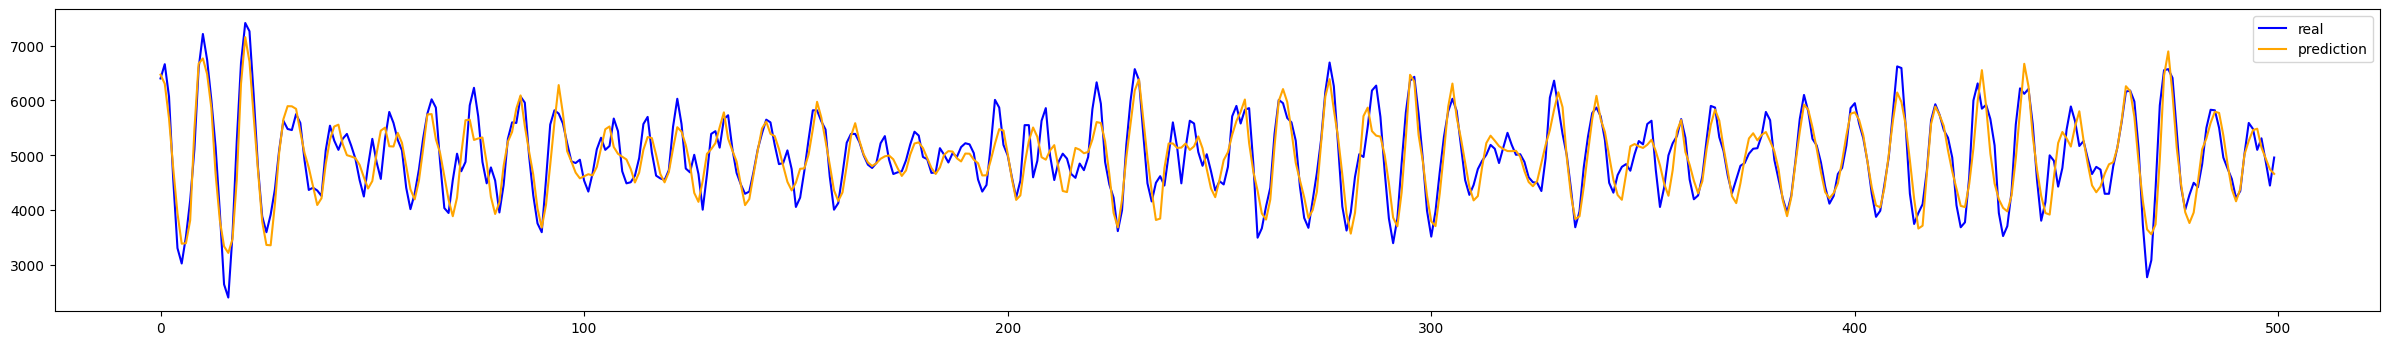

MAE: 279.41474267578127
MAE(sklearn): 279.41474267578127
MAPE(sklearn): 0.0575682190661305
MSE: 123777.49698253332
MSE(sklearn): 123777.49698253332
RMSE(sklearn): 351.82026232514426
Acc: 0.9052075631639454


In [35]:
fan_force150_real3,fan_force150_pre3 = FanGuiHua_force1(valid50_y3_Force1,N_pre50_Y3_Force1)

np.savetxt('force150_步长3.csv',np.hstack((fan_force150_real3,fan_force150_pre3)),delimiter=',')

In [36]:
# 输入50步长输出3步长Force2
force250_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[348:,:], 4, 52)
force250_x3,force250_y3 = split_sequence(force250_scaled3, 50)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [37]:
train_force250_x3, train_force250_y3, valid_force250_x3, valid_force250_y3 = split_train_valid(force250_x3,force250_y3, 6900, 7500, 8000)
train50_x3_Force2, valid50_x3_Force2 = np.hstack((pretrain_heave50_Y3, pretrain_surge50_Y3, pretrain_pitch50_Y3)), np.hstack((pre_heave50_Y3, pre_surge50_Y3, pre_pitch50_Y3))
train50_y3_Force2, valid50_y3_Force2 = train_force250_y3, valid_force250_y3

In [38]:
N_model50_3_Force2, N_history50_3_Force2, N_pre50_train_Y3_Force2, N_pre50_Y3_Force2 = Model_NN(train50_x3_Force2, train50_y3_Force2, valid50_x3_Force2, valid50_y3_Force2, lr=0.01, epochs=1000, batch_size=256)

Train on 600 samples, validate on 500 samples
Epoch 1/1000
 - 0s - loss: 0.1144 - val_loss: 0.0706
Epoch 2/1000
 - 0s - loss: 0.0810 - val_loss: 0.0776
Epoch 3/1000
 - 0s - loss: 0.0763 - val_loss: 0.0559
Epoch 4/1000
 - 0s - loss: 0.0626 - val_loss: 0.0565
Epoch 5/1000
 - 0s - loss: 0.0627 - val_loss: 0.0540
Epoch 6/1000
 - 0s - loss: 0.0583 - val_loss: 0.0472
Epoch 7/1000
 - 0s - loss: 0.0525 - val_loss: 0.0494
Epoch 8/1000
 - 0s - loss: 0.0533 - val_loss: 0.0487
Epoch 9/1000
 - 0s - loss: 0.0511 - val_loss: 0.0441
Epoch 10/1000
 - 0s - loss: 0.0473 - val_loss: 0.0452
Epoch 11/1000
 - 0s - loss: 0.0468 - val_loss: 0.0453
Epoch 12/1000
 - 0s - loss: 0.0458 - val_loss: 0.0465
Epoch 13/1000
 - 0s - loss: 0.0468 - val_loss: 0.0485
Epoch 14/1000
 - 0s - loss: 0.0475 - val_loss: 0.0477
Epoch 15/1000
 - 0s - loss: 0.0469 - val_loss: 0.0481
Epoch 16/1000
 - 0s - loss: 0.0467 - val_loss: 0.0475
Epoch 17/1000
 - 0s - loss: 0.0467 - val_loss: 0.0472
Epoch 18/1000
 - 0s - loss: 0.0467 - val_loss

Epoch 152/1000
 - 0s - loss: 0.0461 - val_loss: 0.0457
Epoch 153/1000
 - 0s - loss: 0.0461 - val_loss: 0.0457
Epoch 154/1000
 - 0s - loss: 0.0461 - val_loss: 0.0457
Epoch 155/1000
 - 0s - loss: 0.0461 - val_loss: 0.0457
Epoch 156/1000
 - 0s - loss: 0.0461 - val_loss: 0.0457
Epoch 157/1000
 - 0s - loss: 0.0461 - val_loss: 0.0457
Epoch 158/1000
 - 0s - loss: 0.0461 - val_loss: 0.0457
Epoch 159/1000
 - 0s - loss: 0.0461 - val_loss: 0.0457
Epoch 160/1000
 - 0s - loss: 0.0461 - val_loss: 0.0457
Epoch 161/1000
 - 0s - loss: 0.0461 - val_loss: 0.0457
Epoch 162/1000
 - 0s - loss: 0.0461 - val_loss: 0.0457
Epoch 163/1000
 - 0s - loss: 0.0461 - val_loss: 0.0457
Epoch 164/1000
 - 0s - loss: 0.0461 - val_loss: 0.0457
Epoch 165/1000
 - 0s - loss: 0.0461 - val_loss: 0.0457
Epoch 166/1000
 - 0s - loss: 0.0461 - val_loss: 0.0457
Epoch 167/1000
 - 0s - loss: 0.0461 - val_loss: 0.0457
Epoch 168/1000
 - 0s - loss: 0.0461 - val_loss: 0.0457
Epoch 169/1000
 - 0s - loss: 0.0461 - val_loss: 0.0457
Epoch 170/

Epoch 301/1000
 - 0s - loss: 0.0460 - val_loss: 0.0456
Epoch 302/1000
 - 0s - loss: 0.0460 - val_loss: 0.0456
Epoch 303/1000
 - 0s - loss: 0.0460 - val_loss: 0.0456
Epoch 304/1000
 - 0s - loss: 0.0460 - val_loss: 0.0456
Epoch 305/1000
 - 0s - loss: 0.0460 - val_loss: 0.0456
Epoch 306/1000
 - 0s - loss: 0.0460 - val_loss: 0.0456
Epoch 307/1000
 - 0s - loss: 0.0460 - val_loss: 0.0456
Epoch 308/1000
 - 0s - loss: 0.0460 - val_loss: 0.0456
Epoch 309/1000
 - 0s - loss: 0.0460 - val_loss: 0.0456
Epoch 310/1000
 - 0s - loss: 0.0460 - val_loss: 0.0456
Epoch 311/1000
 - 0s - loss: 0.0460 - val_loss: 0.0456
Epoch 312/1000
 - 0s - loss: 0.0460 - val_loss: 0.0456
Epoch 313/1000
 - 0s - loss: 0.0460 - val_loss: 0.0456
Epoch 314/1000
 - 0s - loss: 0.0460 - val_loss: 0.0456
Epoch 315/1000
 - 0s - loss: 0.0460 - val_loss: 0.0456
Epoch 316/1000
 - 0s - loss: 0.0460 - val_loss: 0.0456
Epoch 317/1000
 - 0s - loss: 0.0460 - val_loss: 0.0456
Epoch 318/1000
 - 0s - loss: 0.0460 - val_loss: 0.0456
Epoch 319/

Epoch 450/1000
 - 0s - loss: 0.0450 - val_loss: 0.0466
Epoch 451/1000
 - 0s - loss: 0.0450 - val_loss: 0.0467
Epoch 452/1000
 - 0s - loss: 0.0450 - val_loss: 0.0467
Epoch 453/1000
 - 0s - loss: 0.0450 - val_loss: 0.0467
Epoch 454/1000
 - 0s - loss: 0.0449 - val_loss: 0.0467
Epoch 455/1000
 - 0s - loss: 0.0449 - val_loss: 0.0467
Epoch 456/1000
 - 0s - loss: 0.0449 - val_loss: 0.0467
Epoch 457/1000
 - 0s - loss: 0.0449 - val_loss: 0.0468
Epoch 458/1000
 - 0s - loss: 0.0449 - val_loss: 0.0468
Epoch 459/1000
 - 0s - loss: 0.0449 - val_loss: 0.0468
Epoch 460/1000
 - 0s - loss: 0.0449 - val_loss: 0.0468
Epoch 461/1000
 - 0s - loss: 0.0448 - val_loss: 0.0469
Epoch 462/1000
 - 0s - loss: 0.0448 - val_loss: 0.0469
Epoch 463/1000
 - 0s - loss: 0.0448 - val_loss: 0.0469
Epoch 464/1000
 - 0s - loss: 0.0448 - val_loss: 0.0469
Epoch 465/1000
 - 0s - loss: 0.0448 - val_loss: 0.0470
Epoch 466/1000
 - 0s - loss: 0.0448 - val_loss: 0.0470
Epoch 467/1000
 - 0s - loss: 0.0448 - val_loss: 0.0470
Epoch 468/

Epoch 599/1000
 - 0s - loss: 0.0444 - val_loss: 0.0475
Epoch 600/1000
 - 0s - loss: 0.0444 - val_loss: 0.0475
Epoch 601/1000
 - 0s - loss: 0.0444 - val_loss: 0.0475
Epoch 602/1000
 - 0s - loss: 0.0444 - val_loss: 0.0475
Epoch 603/1000
 - 0s - loss: 0.0444 - val_loss: 0.0475
Epoch 604/1000
 - 0s - loss: 0.0444 - val_loss: 0.0475
Epoch 605/1000
 - 0s - loss: 0.0444 - val_loss: 0.0475
Epoch 606/1000
 - 0s - loss: 0.0444 - val_loss: 0.0475
Epoch 607/1000
 - 0s - loss: 0.0444 - val_loss: 0.0475
Epoch 608/1000
 - 0s - loss: 0.0444 - val_loss: 0.0475
Epoch 609/1000
 - 0s - loss: 0.0443 - val_loss: 0.0475
Epoch 610/1000
 - 0s - loss: 0.0443 - val_loss: 0.0475
Epoch 611/1000
 - 0s - loss: 0.0443 - val_loss: 0.0475
Epoch 612/1000
 - 0s - loss: 0.0443 - val_loss: 0.0475
Epoch 613/1000
 - 0s - loss: 0.0443 - val_loss: 0.0475
Epoch 614/1000
 - 0s - loss: 0.0443 - val_loss: 0.0475
Epoch 615/1000
 - 0s - loss: 0.0443 - val_loss: 0.0475
Epoch 616/1000
 - 0s - loss: 0.0443 - val_loss: 0.0475
Epoch 617/

Epoch 748/1000
 - 0s - loss: 0.0437 - val_loss: 0.0471
Epoch 749/1000
 - 0s - loss: 0.0437 - val_loss: 0.0471
Epoch 750/1000
 - 0s - loss: 0.0437 - val_loss: 0.0472
Epoch 751/1000
 - 0s - loss: 0.0437 - val_loss: 0.0472
Epoch 752/1000
 - 0s - loss: 0.0437 - val_loss: 0.0472
Epoch 753/1000
 - 0s - loss: 0.0437 - val_loss: 0.0472
Epoch 754/1000
 - 0s - loss: 0.0437 - val_loss: 0.0472
Epoch 755/1000
 - 0s - loss: 0.0437 - val_loss: 0.0472
Epoch 756/1000
 - 0s - loss: 0.0437 - val_loss: 0.0472
Epoch 757/1000
 - 0s - loss: 0.0437 - val_loss: 0.0472
Epoch 758/1000
 - 0s - loss: 0.0437 - val_loss: 0.0472
Epoch 759/1000
 - 0s - loss: 0.0437 - val_loss: 0.0472
Epoch 760/1000
 - 0s - loss: 0.0437 - val_loss: 0.0472
Epoch 761/1000
 - 0s - loss: 0.0437 - val_loss: 0.0472
Epoch 762/1000
 - 0s - loss: 0.0437 - val_loss: 0.0472
Epoch 763/1000
 - 0s - loss: 0.0437 - val_loss: 0.0472
Epoch 764/1000
 - 0s - loss: 0.0436 - val_loss: 0.0472
Epoch 765/1000
 - 0s - loss: 0.0436 - val_loss: 0.0472
Epoch 766/

Epoch 897/1000
 - 0s - loss: 0.0435 - val_loss: 0.0486
Epoch 898/1000
 - 0s - loss: 0.0435 - val_loss: 0.0486
Epoch 899/1000
 - 0s - loss: 0.0435 - val_loss: 0.0486
Epoch 900/1000
 - 0s - loss: 0.0435 - val_loss: 0.0486
Epoch 901/1000
 - 0s - loss: 0.0435 - val_loss: 0.0486
Epoch 902/1000
 - 0s - loss: 0.0435 - val_loss: 0.0486
Epoch 903/1000
 - 0s - loss: 0.0435 - val_loss: 0.0486
Epoch 904/1000
 - 0s - loss: 0.0435 - val_loss: 0.0486
Epoch 905/1000
 - 0s - loss: 0.0435 - val_loss: 0.0486
Epoch 906/1000
 - 0s - loss: 0.0435 - val_loss: 0.0486
Epoch 907/1000
 - 0s - loss: 0.0435 - val_loss: 0.0486
Epoch 908/1000
 - 0s - loss: 0.0435 - val_loss: 0.0486
Epoch 909/1000
 - 0s - loss: 0.0435 - val_loss: 0.0486
Epoch 910/1000
 - 0s - loss: 0.0435 - val_loss: 0.0486
Epoch 911/1000
 - 0s - loss: 0.0435 - val_loss: 0.0486
Epoch 912/1000
 - 0s - loss: 0.0435 - val_loss: 0.0486
Epoch 913/1000
 - 0s - loss: 0.0435 - val_loss: 0.0486
Epoch 914/1000
 - 0s - loss: 0.0435 - val_loss: 0.0486
Epoch 915/

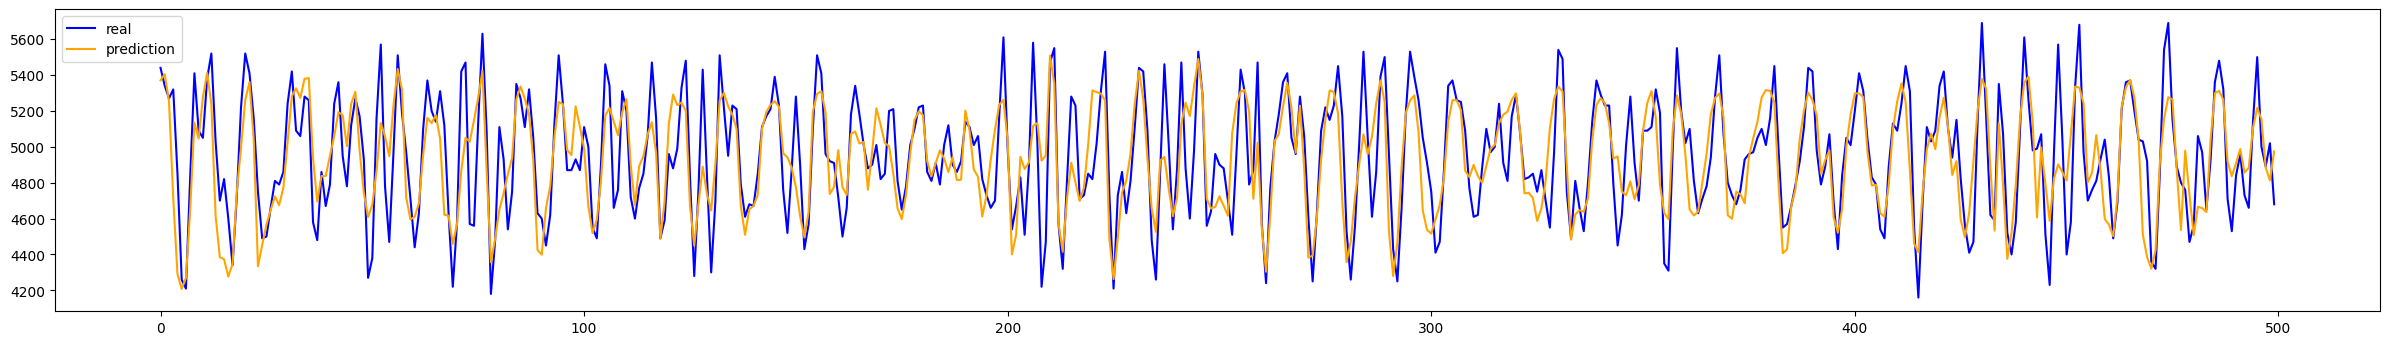

MAE: 174.330015625
MAE(sklearn): 174.330015625
MAPE(sklearn): 0.03539202915893415
MSE: 49524.06590896797
MSE(sklearn): 49524.06590896797
RMSE(sklearn): 222.54003214920223
Acc: 0.8911615176065321


In [39]:
fan_force250_real3,fan_force250_pre3 = FanGuiHua_force2(valid50_y3_Force2,N_pre50_Y3_Force2)

np.savetxt('force250_步长3.csv',np.hstack((fan_force250_real3,fan_force250_pre3)),delimiter=',')

#### 系泊缆力联合预测（时间窗50输出；步长4）

In [40]:
# 未来运动预测模型建立
train_heave50_x4, train_heave50_y4, valid_heave50_x4, valid_heave50_y4 = split_train_valid(heave50_x4,heave50_y4, 6900, 7500, 8000)
heave50_model4, heave50_history4, pre_heave50_Y4 = Model_LSTM(train_heave50_x4, train_heave50_y4, valid_heave50_x4, valid_heave50_y4, lr=0.1, epochs=30, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x4, train_surge50_y4, valid_surge50_x4, valid_surge50_y4 = split_train_valid(surge50_x4,surge50_y4, 6600, 7500, 8000)
surge50_model4, surge50_history4, pre_surge50_Y4 = Model_LSTM(train_surge50_x4, train_surge50_y4, valid_surge50_x4, valid_surge50_y4, lr=1.3, epochs=30, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x4, train_pitch50_y4, valid_pitch50_x4, valid_pitch50_y4 = split_train_valid(pitch50_x4,pitch50_y4, 6900, 7500, 8000)
pitch50_model4, pitch50_history4, pre_pitch50_Y4 = Model_LSTM(train_pitch50_x4, train_pitch50_y4, valid_pitch50_x4, valid_pitch50_y4, lr=0.35, epochs=30, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Train on 600 samples, validate on 500 samples
Epoch 1/30
 - 0s - loss: 0.0566 - val_loss: 0.0673
Epoch 2/30
 - 0s - loss: 0.0499 - val_loss: 0.0611
Epoch 3/30
 - 0s - loss: 0.0454 - val_loss: 0.0549
Epoch 4/30
 - 0s - loss: 0.0409 - val_loss: 0.0483
Epoch 5/30
 - 0s - loss: 0.0361 - val_loss: 0.0411
Epoch 6/30
 - 0s - loss: 0.0307 - val_loss: 0.0327
Epoch 7/30
 - 0s - loss: 0.0248 - val_loss: 0.0239
Epoch 8/30
 - 0s - loss: 0.0207 - val_loss: 0.0215
Epoch 9/30
 - 0s - loss: 0.0198 - val_loss: 0.0210
Epoch 10/30
 - 0s - loss: 0.0192 - val_loss: 0.0203
Epoch 11/30
 - 0s - loss: 0.0186 - val_loss: 0.0198
Epoch 12/30
 - 0s - loss: 0.0182 - val_loss: 0.0192
Epoch 13/30
 - 0s - loss: 0.0177 - val_loss: 0.0189
Epoch 14/30
 - 0s - loss: 0.0174 - val_loss: 0.0185
Epoch 15/30
 - 0s - loss: 0.0170 - val_loss: 0.0180
Epoch 16/30
 - 0s - loss: 0.0167 - val_loss: 0.0176
Epoch 17/30
 - 0s - loss: 0.0162 - val_loss: 0.0169
Epoch 18/30
 - 0s - loss: 0.0157 - val_loss: 0.0163
Epoch 19/30
 - 0s - loss: 0

In [41]:
pretrain_heave50_Y4 = heave50_model4.predict(train_heave50_x4)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y4 = surge50_model4.predict(train_surge50_x4[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y4 = pitch50_model4.predict(train_pitch50_x4)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y4.shape)
print(pretrain_surge50_Y4.shape)
print(pretrain_pitch50_Y4.shape)

(600, 1)
(600, 1)
(600, 1)


In [42]:
# 输入50步长输出4步长Force1
force150_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[347:,:], 4, 53)
force150_x4,force150_y4 = split_sequence(force150_scaled4, 50)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [43]:
train_force150_x4, train_force150_y4, valid_force150_x4, valid_force150_y4 = split_train_valid(force150_x4,force150_y4, 6900, 7500, 8000)
train50_x4_Force1, valid50_x4_Force1 = np.hstack((pretrain_heave50_Y4, pretrain_surge50_Y4, pretrain_pitch50_Y4)), np.hstack((pre_heave50_Y4, pre_surge50_Y4, pre_pitch50_Y4))
train50_y4_Force1, valid50_y4_Force1 = train_force150_y4, valid_force150_y4

In [44]:
N_model50_4_Force1, N_history50_4_Force1, N_pre50_train_Y4_Force1, N_pre50_Y4_Force1 = Model_NN(train50_x4_Force1, train50_y4_Force1, valid50_x4_Force1, valid50_y4_Force1, lr=0.01, epochs=1000, batch_size=256)

Train on 600 samples, validate on 500 samples
Epoch 1/1000
 - 0s - loss: 0.0310 - val_loss: 0.0302
Epoch 2/1000
 - 0s - loss: 0.0276 - val_loss: 0.0174
Epoch 3/1000
 - 0s - loss: 0.0158 - val_loss: 0.0223
Epoch 4/1000
 - 0s - loss: 0.0193 - val_loss: 0.0227
Epoch 5/1000
 - 0s - loss: 0.0185 - val_loss: 0.0168
Epoch 6/1000
 - 0s - loss: 0.0156 - val_loss: 0.0168
Epoch 7/1000
 - 0s - loss: 0.0166 - val_loss: 0.0169
Epoch 8/1000
 - 0s - loss: 0.0160 - val_loss: 0.0164
Epoch 9/1000
 - 0s - loss: 0.0153 - val_loss: 0.0175
Epoch 10/1000
 - 0s - loss: 0.0158 - val_loss: 0.0175
Epoch 11/1000
 - 0s - loss: 0.0157 - val_loss: 0.0164
Epoch 12/1000
 - 0s - loss: 0.0152 - val_loss: 0.0161
Epoch 13/1000
 - 0s - loss: 0.0153 - val_loss: 0.0161
Epoch 14/1000
 - 0s - loss: 0.0152 - val_loss: 0.0162
Epoch 15/1000
 - 0s - loss: 0.0151 - val_loss: 0.0166
Epoch 16/1000
 - 0s - loss: 0.0152 - val_loss: 0.0165
Epoch 17/1000
 - 0s - loss: 0.0152 - val_loss: 0.0162
Epoch 18/1000
 - 0s - loss: 0.0151 - val_loss

 - 0s - loss: 0.0150 - val_loss: 0.0162
Epoch 152/1000
 - 0s - loss: 0.0150 - val_loss: 0.0162
Epoch 153/1000
 - 0s - loss: 0.0150 - val_loss: 0.0162
Epoch 154/1000
 - 0s - loss: 0.0150 - val_loss: 0.0162
Epoch 155/1000
 - 0s - loss: 0.0150 - val_loss: 0.0162
Epoch 156/1000
 - 0s - loss: 0.0150 - val_loss: 0.0162
Epoch 157/1000
 - 0s - loss: 0.0150 - val_loss: 0.0162
Epoch 158/1000
 - 0s - loss: 0.0150 - val_loss: 0.0162
Epoch 159/1000
 - 0s - loss: 0.0150 - val_loss: 0.0162
Epoch 160/1000
 - 0s - loss: 0.0150 - val_loss: 0.0162
Epoch 161/1000
 - 0s - loss: 0.0150 - val_loss: 0.0162
Epoch 162/1000
 - 0s - loss: 0.0150 - val_loss: 0.0162
Epoch 163/1000
 - 0s - loss: 0.0150 - val_loss: 0.0162
Epoch 164/1000
 - 0s - loss: 0.0150 - val_loss: 0.0162
Epoch 165/1000
 - 0s - loss: 0.0150 - val_loss: 0.0162
Epoch 166/1000
 - 0s - loss: 0.0150 - val_loss: 0.0162
Epoch 167/1000
 - 0s - loss: 0.0150 - val_loss: 0.0162
Epoch 168/1000
 - 0s - loss: 0.0150 - val_loss: 0.0162
Epoch 169/1000
 - 0s - lo

Epoch 301/1000
 - 0s - loss: 0.0150 - val_loss: 0.0164
Epoch 302/1000
 - 0s - loss: 0.0150 - val_loss: 0.0164
Epoch 303/1000
 - 0s - loss: 0.0150 - val_loss: 0.0164
Epoch 304/1000
 - 0s - loss: 0.0150 - val_loss: 0.0164
Epoch 305/1000
 - 0s - loss: 0.0150 - val_loss: 0.0164
Epoch 306/1000
 - 0s - loss: 0.0150 - val_loss: 0.0164
Epoch 307/1000
 - 0s - loss: 0.0150 - val_loss: 0.0164
Epoch 308/1000
 - 0s - loss: 0.0150 - val_loss: 0.0164
Epoch 309/1000
 - 0s - loss: 0.0149 - val_loss: 0.0164
Epoch 310/1000
 - 0s - loss: 0.0149 - val_loss: 0.0164
Epoch 311/1000
 - 0s - loss: 0.0149 - val_loss: 0.0164
Epoch 312/1000
 - 0s - loss: 0.0149 - val_loss: 0.0164
Epoch 313/1000
 - 0s - loss: 0.0149 - val_loss: 0.0164
Epoch 314/1000
 - 0s - loss: 0.0149 - val_loss: 0.0164
Epoch 315/1000
 - 0s - loss: 0.0149 - val_loss: 0.0164
Epoch 316/1000
 - 0s - loss: 0.0149 - val_loss: 0.0164
Epoch 317/1000
 - 0s - loss: 0.0149 - val_loss: 0.0164
Epoch 318/1000
 - 0s - loss: 0.0149 - val_loss: 0.0164
Epoch 319/

Epoch 450/1000
 - 0s - loss: 0.0149 - val_loss: 0.0165
Epoch 451/1000
 - 0s - loss: 0.0149 - val_loss: 0.0165
Epoch 452/1000
 - 0s - loss: 0.0149 - val_loss: 0.0165
Epoch 453/1000
 - 0s - loss: 0.0149 - val_loss: 0.0165
Epoch 454/1000
 - 0s - loss: 0.0149 - val_loss: 0.0165
Epoch 455/1000
 - 0s - loss: 0.0149 - val_loss: 0.0165
Epoch 456/1000
 - 0s - loss: 0.0149 - val_loss: 0.0165
Epoch 457/1000
 - 0s - loss: 0.0149 - val_loss: 0.0165
Epoch 458/1000
 - 0s - loss: 0.0149 - val_loss: 0.0165
Epoch 459/1000
 - 0s - loss: 0.0149 - val_loss: 0.0165
Epoch 460/1000
 - 0s - loss: 0.0149 - val_loss: 0.0165
Epoch 461/1000
 - 0s - loss: 0.0149 - val_loss: 0.0165
Epoch 462/1000
 - 0s - loss: 0.0149 - val_loss: 0.0165
Epoch 463/1000
 - 0s - loss: 0.0149 - val_loss: 0.0165
Epoch 464/1000
 - 0s - loss: 0.0149 - val_loss: 0.0165
Epoch 465/1000
 - 0s - loss: 0.0149 - val_loss: 0.0165
Epoch 466/1000
 - 0s - loss: 0.0149 - val_loss: 0.0165
Epoch 467/1000
 - 0s - loss: 0.0149 - val_loss: 0.0165
Epoch 468/

Epoch 599/1000
 - 0s - loss: 0.0148 - val_loss: 0.0165
Epoch 600/1000
 - 0s - loss: 0.0148 - val_loss: 0.0165
Epoch 601/1000
 - 0s - loss: 0.0148 - val_loss: 0.0165
Epoch 602/1000
 - 0s - loss: 0.0148 - val_loss: 0.0165
Epoch 603/1000
 - 0s - loss: 0.0148 - val_loss: 0.0165
Epoch 604/1000
 - 0s - loss: 0.0148 - val_loss: 0.0165
Epoch 605/1000
 - 0s - loss: 0.0148 - val_loss: 0.0165
Epoch 606/1000
 - 0s - loss: 0.0148 - val_loss: 0.0165
Epoch 607/1000
 - 0s - loss: 0.0148 - val_loss: 0.0165
Epoch 608/1000
 - 0s - loss: 0.0148 - val_loss: 0.0165
Epoch 609/1000
 - 0s - loss: 0.0148 - val_loss: 0.0165
Epoch 610/1000
 - 0s - loss: 0.0148 - val_loss: 0.0165
Epoch 611/1000
 - 0s - loss: 0.0148 - val_loss: 0.0165
Epoch 612/1000
 - 0s - loss: 0.0148 - val_loss: 0.0165
Epoch 613/1000
 - 0s - loss: 0.0148 - val_loss: 0.0165
Epoch 614/1000
 - 0s - loss: 0.0148 - val_loss: 0.0165
Epoch 615/1000
 - 0s - loss: 0.0148 - val_loss: 0.0165
Epoch 616/1000
 - 0s - loss: 0.0148 - val_loss: 0.0165
Epoch 617/

Epoch 748/1000
 - 0s - loss: 0.0148 - val_loss: 0.0162
Epoch 749/1000
 - 0s - loss: 0.0148 - val_loss: 0.0162
Epoch 750/1000
 - 0s - loss: 0.0148 - val_loss: 0.0162
Epoch 751/1000
 - 0s - loss: 0.0148 - val_loss: 0.0162
Epoch 752/1000
 - 0s - loss: 0.0148 - val_loss: 0.0162
Epoch 753/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 754/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 755/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 756/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 757/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 758/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 759/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 760/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 761/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 762/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 763/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 764/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 765/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 766/

Epoch 897/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 898/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 899/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 900/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 901/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 902/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 903/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 904/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 905/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 906/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 907/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 908/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 909/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 910/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 911/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 912/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 913/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 914/1000
 - 0s - loss: 0.0147 - val_loss: 0.0162
Epoch 915/

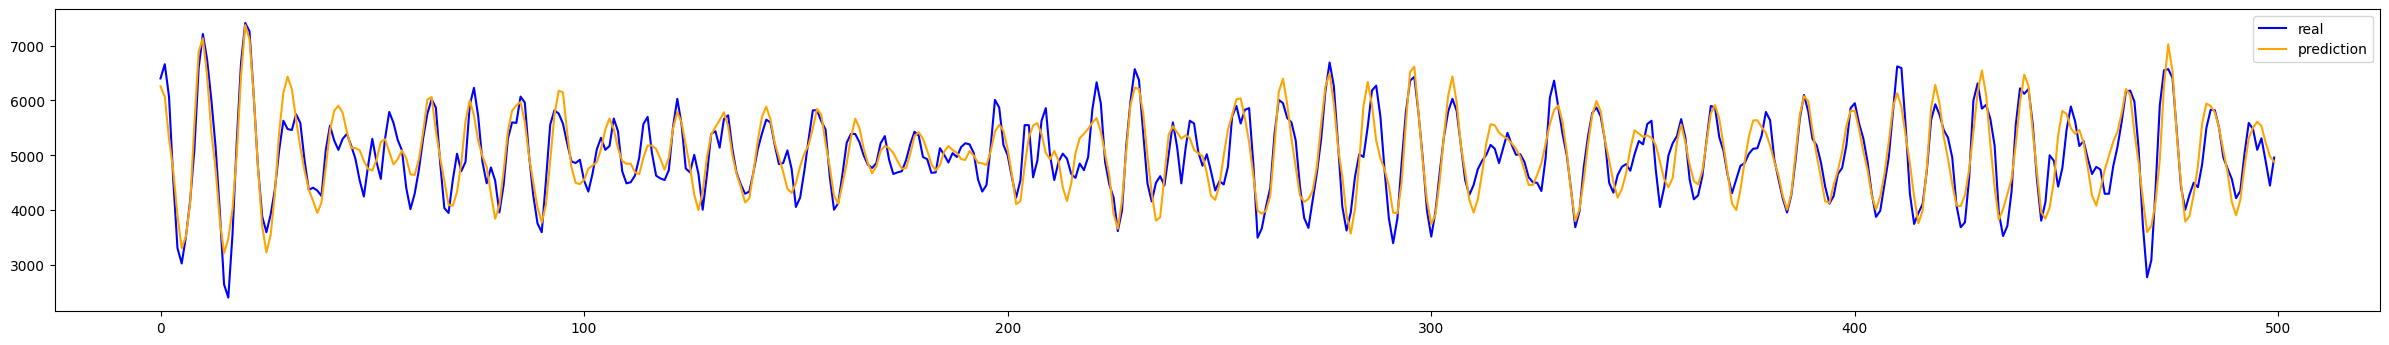

MAE: 287.6811650390625
MAE(sklearn): 287.6811650390625
MAPE(sklearn): 0.05966360966763449
MSE: 132646.37085309267
MSE(sklearn): 132646.37085309267
RMSE(sklearn): 364.2064947980646
Acc: 0.9787818969251454


In [45]:
fan_force150_real4,fan_force150_pre4 = FanGuiHua_force1(valid50_y4_Force1,N_pre50_Y4_Force1)

np.savetxt('force150_步长4.csv',np.hstack((fan_force150_real4,fan_force150_pre4)),delimiter=',')

In [46]:
# 输入50步长输出4步长Force2
force250_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[347:,:], 4, 53)
force250_x4,force250_y4 = split_sequence(force250_scaled4, 50)
# print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

In [47]:
train_force250_x4, train_force250_y4, valid_force250_x4, valid_force250_y4 = split_train_valid(force250_x4,force250_y4, 6900, 7500, 8000)
train50_x4_Force2, valid50_x4_Force2 = np.hstack((pretrain_heave50_Y4, pretrain_surge50_Y4, pretrain_pitch50_Y4)), np.hstack((pre_heave50_Y4, pre_surge50_Y4, pre_pitch50_Y4))
train50_y4_Force2, valid50_y4_Force2 = train_force250_y4, valid_force250_y4

In [48]:
N_model50_4_Force2, N_history50_4_Force2, N_pre50_train_Y4_Force2, N_pre50_Y4_Force2 = Model_NN(train50_x4_Force2, train50_y4_Force2, valid50_x4_Force2, valid50_y4_Force2, lr=0.01, epochs=1000, batch_size=256)

Train on 600 samples, validate on 500 samples
Epoch 1/1000
 - 0s - loss: 0.0932 - val_loss: 0.0824
Epoch 2/1000
 - 0s - loss: 0.0906 - val_loss: 0.0709
Epoch 3/1000
 - 0s - loss: 0.0811 - val_loss: 0.0734
Epoch 4/1000
 - 0s - loss: 0.0820 - val_loss: 0.0730
Epoch 5/1000
 - 0s - loss: 0.0815 - val_loss: 0.0710
Epoch 6/1000
 - 0s - loss: 0.0803 - val_loss: 0.0694
Epoch 7/1000
 - 0s - loss: 0.0799 - val_loss: 0.0696
Epoch 8/1000
 - 0s - loss: 0.0797 - val_loss: 0.0690
Epoch 9/1000
 - 0s - loss: 0.0791 - val_loss: 0.0694
Epoch 10/1000
 - 0s - loss: 0.0794 - val_loss: 0.0696
Epoch 11/1000
 - 0s - loss: 0.0793 - val_loss: 0.0693
Epoch 12/1000
 - 0s - loss: 0.0790 - val_loss: 0.0693
Epoch 13/1000
 - 0s - loss: 0.0790 - val_loss: 0.0689
Epoch 14/1000
 - 0s - loss: 0.0788 - val_loss: 0.0688
Epoch 15/1000
 - 0s - loss: 0.0788 - val_loss: 0.0688
Epoch 16/1000
 - 0s - loss: 0.0788 - val_loss: 0.0688
Epoch 17/1000
 - 0s - loss: 0.0786 - val_loss: 0.0689
Epoch 18/1000
 - 0s - loss: 0.0786 - val_loss

Epoch 152/1000
 - 0s - loss: 0.0778 - val_loss: 0.0696
Epoch 153/1000
 - 0s - loss: 0.0777 - val_loss: 0.0696
Epoch 154/1000
 - 0s - loss: 0.0777 - val_loss: 0.0696
Epoch 155/1000
 - 0s - loss: 0.0777 - val_loss: 0.0696
Epoch 156/1000
 - 0s - loss: 0.0777 - val_loss: 0.0696
Epoch 157/1000
 - 0s - loss: 0.0777 - val_loss: 0.0696
Epoch 158/1000
 - 0s - loss: 0.0777 - val_loss: 0.0696
Epoch 159/1000
 - 0s - loss: 0.0777 - val_loss: 0.0696
Epoch 160/1000
 - 0s - loss: 0.0777 - val_loss: 0.0696
Epoch 161/1000
 - 0s - loss: 0.0777 - val_loss: 0.0696
Epoch 162/1000
 - 0s - loss: 0.0777 - val_loss: 0.0696
Epoch 163/1000
 - 0s - loss: 0.0777 - val_loss: 0.0696
Epoch 164/1000
 - 0s - loss: 0.0777 - val_loss: 0.0696
Epoch 165/1000
 - 0s - loss: 0.0777 - val_loss: 0.0696
Epoch 166/1000
 - 0s - loss: 0.0777 - val_loss: 0.0696
Epoch 167/1000
 - 0s - loss: 0.0777 - val_loss: 0.0696
Epoch 168/1000
 - 0s - loss: 0.0777 - val_loss: 0.0697
Epoch 169/1000
 - 0s - loss: 0.0777 - val_loss: 0.0697
Epoch 170/

Epoch 301/1000
 - 0s - loss: 0.0772 - val_loss: 0.0716
Epoch 302/1000
 - 0s - loss: 0.0778 - val_loss: 0.0725
Epoch 303/1000
 - 0s - loss: 0.0786 - val_loss: 0.0721
Epoch 304/1000
 - 0s - loss: 0.0777 - val_loss: 0.0719
Epoch 305/1000
 - 0s - loss: 0.0774 - val_loss: 0.0736
Epoch 306/1000
 - 0s - loss: 0.0774 - val_loss: 0.0715
Epoch 307/1000
 - 0s - loss: 0.0770 - val_loss: 0.0716
Epoch 308/1000
 - 0s - loss: 0.0770 - val_loss: 0.0722
Epoch 309/1000
 - 0s - loss: 0.0769 - val_loss: 0.0720
Epoch 310/1000
 - 0s - loss: 0.0768 - val_loss: 0.0718
Epoch 311/1000
 - 0s - loss: 0.0770 - val_loss: 0.0720
Epoch 312/1000
 - 0s - loss: 0.0767 - val_loss: 0.0724
Epoch 313/1000
 - 0s - loss: 0.0767 - val_loss: 0.0721
Epoch 314/1000
 - 0s - loss: 0.0767 - val_loss: 0.0722
Epoch 315/1000
 - 0s - loss: 0.0767 - val_loss: 0.0725
Epoch 316/1000
 - 0s - loss: 0.0766 - val_loss: 0.0725
Epoch 317/1000
 - 0s - loss: 0.0766 - val_loss: 0.0724
Epoch 318/1000
 - 0s - loss: 0.0766 - val_loss: 0.0726
Epoch 319/

Epoch 450/1000
 - 0s - loss: 0.0750 - val_loss: 0.0771
Epoch 451/1000
 - 0s - loss: 0.0750 - val_loss: 0.0771
Epoch 452/1000
 - 0s - loss: 0.0750 - val_loss: 0.0771
Epoch 453/1000
 - 0s - loss: 0.0750 - val_loss: 0.0772
Epoch 454/1000
 - 0s - loss: 0.0750 - val_loss: 0.0772
Epoch 455/1000
 - 0s - loss: 0.0750 - val_loss: 0.0772
Epoch 456/1000
 - 0s - loss: 0.0750 - val_loss: 0.0772
Epoch 457/1000
 - 0s - loss: 0.0750 - val_loss: 0.0772
Epoch 458/1000
 - 0s - loss: 0.0750 - val_loss: 0.0772
Epoch 459/1000
 - 0s - loss: 0.0750 - val_loss: 0.0773
Epoch 460/1000
 - 0s - loss: 0.0749 - val_loss: 0.0773
Epoch 461/1000
 - 0s - loss: 0.0749 - val_loss: 0.0773
Epoch 462/1000
 - 0s - loss: 0.0749 - val_loss: 0.0773
Epoch 463/1000
 - 0s - loss: 0.0749 - val_loss: 0.0773
Epoch 464/1000
 - 0s - loss: 0.0749 - val_loss: 0.0773
Epoch 465/1000
 - 0s - loss: 0.0749 - val_loss: 0.0773
Epoch 466/1000
 - 0s - loss: 0.0749 - val_loss: 0.0773
Epoch 467/1000
 - 0s - loss: 0.0749 - val_loss: 0.0773
Epoch 468/

Epoch 599/1000
 - 0s - loss: 0.0737 - val_loss: 0.0801
Epoch 600/1000
 - 0s - loss: 0.0737 - val_loss: 0.0802
Epoch 601/1000
 - 0s - loss: 0.0736 - val_loss: 0.0804
Epoch 602/1000
 - 0s - loss: 0.0736 - val_loss: 0.0808
Epoch 603/1000
 - 0s - loss: 0.0738 - val_loss: 0.0808
Epoch 604/1000
 - 0s - loss: 0.0737 - val_loss: 0.0805
Epoch 605/1000
 - 0s - loss: 0.0735 - val_loss: 0.0804
Epoch 606/1000
 - 0s - loss: 0.0735 - val_loss: 0.0805
Epoch 607/1000
 - 0s - loss: 0.0735 - val_loss: 0.0807
Epoch 608/1000
 - 0s - loss: 0.0736 - val_loss: 0.0807
Epoch 609/1000
 - 0s - loss: 0.0736 - val_loss: 0.0806
Epoch 610/1000
 - 0s - loss: 0.0735 - val_loss: 0.0805
Epoch 611/1000
 - 0s - loss: 0.0735 - val_loss: 0.0806
Epoch 612/1000
 - 0s - loss: 0.0735 - val_loss: 0.0808
Epoch 613/1000
 - 0s - loss: 0.0735 - val_loss: 0.0809
Epoch 614/1000
 - 0s - loss: 0.0735 - val_loss: 0.0809
Epoch 615/1000
 - 0s - loss: 0.0735 - val_loss: 0.0808
Epoch 616/1000
 - 0s - loss: 0.0735 - val_loss: 0.0808
Epoch 617/

Epoch 748/1000
 - 0s - loss: 0.0725 - val_loss: 0.0815
Epoch 749/1000
 - 0s - loss: 0.0722 - val_loss: 0.0824
Epoch 750/1000
 - 0s - loss: 0.0725 - val_loss: 0.0814
Epoch 751/1000
 - 0s - loss: 0.0722 - val_loss: 0.0826
Epoch 752/1000
 - 0s - loss: 0.0725 - val_loss: 0.0813
Epoch 753/1000
 - 0s - loss: 0.0721 - val_loss: 0.0829
Epoch 754/1000
 - 0s - loss: 0.0726 - val_loss: 0.0812
Epoch 755/1000
 - 0s - loss: 0.0720 - val_loss: 0.0832
Epoch 756/1000
 - 0s - loss: 0.0726 - val_loss: 0.0811
Epoch 757/1000
 - 0s - loss: 0.0720 - val_loss: 0.0837
Epoch 758/1000
 - 0s - loss: 0.0728 - val_loss: 0.0811
Epoch 759/1000
 - 0s - loss: 0.0719 - val_loss: 0.0844
Epoch 760/1000
 - 0s - loss: 0.0730 - val_loss: 0.0810
Epoch 761/1000
 - 0s - loss: 0.0719 - val_loss: 0.0853
Epoch 762/1000
 - 0s - loss: 0.0733 - val_loss: 0.0811
Epoch 763/1000
 - 0s - loss: 0.0720 - val_loss: 0.0866
Epoch 764/1000
 - 0s - loss: 0.0737 - val_loss: 0.0814
Epoch 765/1000
 - 0s - loss: 0.0722 - val_loss: 0.0884
Epoch 766/

Epoch 897/1000
 - 0s - loss: 0.0704 - val_loss: 0.0868
Epoch 898/1000
 - 0s - loss: 0.0704 - val_loss: 0.0869
Epoch 899/1000
 - 0s - loss: 0.0704 - val_loss: 0.0869
Epoch 900/1000
 - 0s - loss: 0.0704 - val_loss: 0.0869
Epoch 901/1000
 - 0s - loss: 0.0704 - val_loss: 0.0870
Epoch 902/1000
 - 0s - loss: 0.0704 - val_loss: 0.0870
Epoch 903/1000
 - 0s - loss: 0.0704 - val_loss: 0.0870
Epoch 904/1000
 - 0s - loss: 0.0703 - val_loss: 0.0871
Epoch 905/1000
 - 0s - loss: 0.0703 - val_loss: 0.0871
Epoch 906/1000
 - 0s - loss: 0.0703 - val_loss: 0.0871
Epoch 907/1000
 - 0s - loss: 0.0703 - val_loss: 0.0872
Epoch 908/1000
 - 0s - loss: 0.0703 - val_loss: 0.0872
Epoch 909/1000
 - 0s - loss: 0.0703 - val_loss: 0.0872
Epoch 910/1000
 - 0s - loss: 0.0703 - val_loss: 0.0873
Epoch 911/1000
 - 0s - loss: 0.0703 - val_loss: 0.0873
Epoch 912/1000
 - 0s - loss: 0.0703 - val_loss: 0.0873
Epoch 913/1000
 - 0s - loss: 0.0702 - val_loss: 0.0874
Epoch 914/1000
 - 0s - loss: 0.0702 - val_loss: 0.0874
Epoch 915/

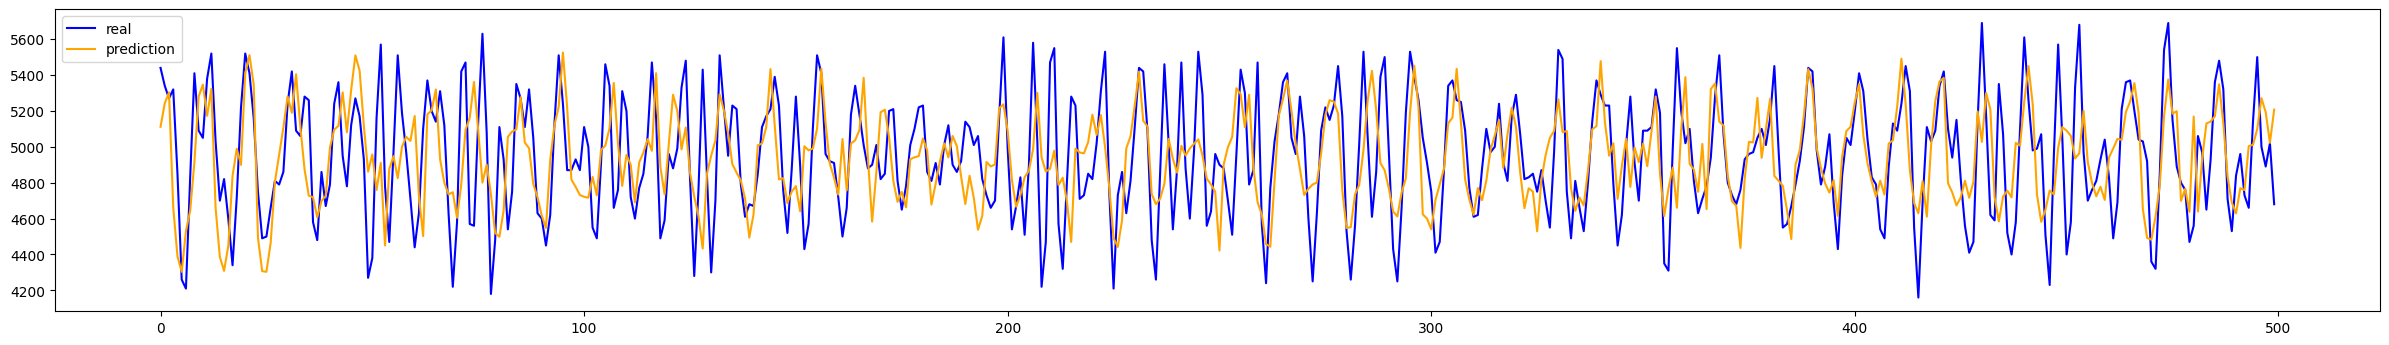

MAE: 241.6943759765625
MAE(sklearn): 241.6943759765625
MAPE(sklearn): 0.049031706924599974
MSE: 92059.25509868574
MSE(sklearn): 92059.25509868574
RMSE(sklearn): 303.412681176456
Acc: 0.7514921649189759


In [49]:
fan_force250_real4,fan_force250_pre4 = FanGuiHua_force2(valid50_y4_Force2,N_pre50_Y4_Force2)

np.savetxt('force250_步长4.csv',np.hstack((fan_force250_real4,fan_force250_pre4)),delimiter=',')